In [1]:
import pandas as pd
import numpy as np
import gc
from IPython.display import display
from mnp.ingestion.loader import load_endes
from mnp.utils.profiler import centrar_notebook
from mnp.utils.cleaning import run_phase1_engine
# Configuración visual
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
centrar_notebook()

print("[OK]")

2026-06-10 21:04:54.492 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /Users/abelguevarah/Desktop/invs/malnutrition-research


[OK]


In [2]:
# Carga de datos
history = load_endes(
        year=range(2007, 2025),
        module="anthropometry",
        record="rech6",
        meta=True
    )

dfs = []
col_labels_hist = {}
val_labels_hist = {}

for year in sorted(list(history.keys())):
    year_df, year_meta = history.pop(year)
    col_labels_hist[year] = year_meta.column_names_to_labels
    val_labels_hist[year] = year_meta.variable_value_labels
    
    dfs.append(year_df.assign(year=year))

df_raw = pd.concat(dfs, ignore_index=True)
del dfs
gc.collect()

print(f"[OK] Data RECH6 cargada: {len(df_raw)} filas y {df_raw.shape[1]} columnas.")
print(f"[OK] Diccionario cargado: {len(col_labels_hist)} Column Labels, {len(val_labels_hist)} Value Labels")

2026-06-10 21:04:55.661 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH6.SAV desde Modulo74 [Alias: rech6]
2026-06-10 21:04:55.778 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH6.SAV desde Modulo74 [Alias: rech6]
2026-06-10 21:04:55.886 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH6.SAV desde Modulo74 [Alias: rech6]
2026-06-10 21:04:56.093 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH6.SAV desde Modulo74 [Alias: rech6]
2026-06-10 21:04:56.207 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH6.sav desde Modulo74 [Alias: rech6]
2026-06-10 21:04:56.340 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH6.sav desde Modulo74 [Alias: rech6]
2026-06-10 21:04:56.477 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH6.SAV desde Modulo74 [Alias: rech6]
2026-06-10 21:04:56.607 | INFO     | mnp.ingesti

In [3]:
# Inspeccionar variable
df_raw['HC51'].value_counts(dropna=False)
df_raw.head(10)


,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,HC8,HC9,HC10,HC11,HC12,HC13,HC15,HC16,HC17,HC18,HC19,HC27,HC30,HC31,HC32,HC33,HC51,HC52,HC53,HC55,HC56,HC57,HC58,HC60,HC61,HC62,HC63,HC64,HC68,HC70,HC71,HC72,HC73,year,f,ID1,HV005A,HC56A,HC57A
0,1 10,3.0,20.0,96.0,766.0,177.0,-210.0,9201.0,830.0,-138.0,8524.0,3494.0,-39.0,9664.0,0.0,1.0,17.0,29.0,3.0,2005.0,2.0,7.0,2003.0,1243.0,1.0,2.0,2.0,NaN,4.0,NaN,NaN,NaN,2.0,3.0,3.0,NaN,1.0,3.0,-214.0,-92.0,18.0,57.0,2007,NaN,NaN,NaN,NaN,NaN
1,1 22,5.0,28.0,137.0,832.0,468.0,-168.0,9355.0,6255.0,32.0,10417.0,9145.0,137.0,11692.0,0.0,2.0,25.0,29.0,3.0,2005.0,1.0,11.0,2002.0,1235.0,1.0,2.0,1.0,111.0,0.0,100.0,3.0,NaN,2.0,1.0,5.0,101.0,3.0,1.0,-221.0,48.0,232.0,268.0,2007,NaN,NaN,NaN,NaN,NaN
2,1 34,3.0,40.0,128.0,920.0,956.0,-131.0,9481.0,948.0,-131.0,8617.0,3078.0,-50.0,9559.0,0.0,2.0,11.0,31.0,3.0,2005.0,2.0,11.0,2001.0,1223.0,1.0,2.0,2.0,NaN,4.0,NaN,NaN,NaN,2.0,3.0,2.0,NaN,1.0,3.0,-153.0,-108.0,-30.0,-15.0,2007,NaN,NaN,NaN,NaN,NaN
3,26 3,4.0,52.0,176.0,1090.0,8757.0,115.0,10461.0,6560.0,40.0,10608.0,4181.0,-21.0,9818.0,0.0,2.0,3.0,15.0,2.0,2005.0,2.0,10.0,2000.0,1210.0,1.0,3.0,1.0,113.0,0.0,98.0,2.0,NaN,3.0,1.0,3.0,80.0,3.0,1.0,83.0,29.0,-37.0,-31.0,2007,NaN,NaN,NaN,NaN,NaN
4,26 3,5.0,34.0,132.0,834.0,37.0,-268.0,8935.0,2494.0,-68.0,9274.0,8395.0,99.0,11223.0,0.0,2.0,22.0,15.0,2.0,2005.0,1.0,4.0,2002.0,1228.0,1.0,3.0,1.0,104.0,0.0,89.0,2.0,NaN,3.0,1.0,3.0,18.0,4.0,1.0,-312.0,-48.0,185.0,235.0,2007,NaN,NaN,NaN,NaN,NaN
5,26 5,6.0,46.0,152.0,910.0,46.0,-260.0,8925.0,2550.0,-66.0,9251.0,8779.0,116.0,11262.0,0.0,2.0,4.0,15.0,2.0,2005.0,1.0,4.0,2001.0,1216.0,1.0,2.0,1.0,125.0,0.0,110.0,3.0,NaN,995.0,NaN,NaN,NaN,NaN,NaN,-277.0,-45.0,179.0,211.0,2007,NaN,NaN,NaN,NaN,NaN
6,26 6,3.0,16.0,112.0,795.0,3192.0,-47.0,9830.0,5117.0,3.0,10032.0,6577.0,41.0,10364.0,0.0,1.0,6.0,17.0,2.0,2005.0,1.0,10.0,2003.0,1246.0,1.0,2.0,1.0,122.0,0.0,107.0,3.0,NaN,2.0,1.0,6.0,NaN,1.0,1.0,-44.0,49.0,93.0,104.0,2007,NaN,NaN,NaN,NaN,NaN
7,26 7,4.0,37.0,118.0,824.0,5.0,-327.0,8706.0,486.0,-166.0,8262.0,6494.0,38.0,10454.0,0.0,2.0,14.0,15.0,2.0,2005.0,2.0,1.0,2002.0,1225.0,1.0,2.0,1.0,144.0,0.0,129.0,4.0,NaN,2.0,1.0,6.0,NaN,1.0,1.0,-347.0,-138.0,101.0,138.0,2007,NaN,NaN,NaN,NaN,NaN
8,26 7,5.0,9.0,82.0,691.0,825.0,-139.0,9496.0,1282.0,-114.0,8814.0,4488.0,-13.0,9885.0,0.0,1.0,7.0,15.0,2.0,2005.0,1.0,5.0,2004.0,1253.0,1.0,2.0,1.0,114.0,0.0,99.0,2.0,NaN,2.0,1.0,6.0,28.0,2.0,1.0,-147.0,-84.0,-3.0,3.0,2007,NaN,NaN,NaN,NaN,NaN
9,26 25,7.0,58.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,18.0,2.0,2005.0,1.0,4.0,2000.0,1204.0,1.0,2.0,2.0,NaN,4.0,NaN,NaN,NaN,2.0,1.0,4.0,27.0,6.0,1.0,NaN,NaN,NaN,NaN,2007,NaN,NaN,NaN,NaN,NaN


In [4]:
from mnp.utils.cleaning import run_phase1_engine
from mnp.configs.rech6 import config_f1

# 3. Limpiar
df_clean = run_phase1_engine(df_raw, config_f1)

print(f'[OK] Limpieza biológica completa. Shape: {df_clean.shape}')
df_clean.head(10)

[Limpieza] Iniciando Motor Fase 1...
[Limpieza] Eliminando 10 columnas (Optimización RAM)...
[Limpieza] Drops iniciales completados en 0.00s
[Limpieza] Casteando 4 columnas clave...
[Limpieza] Casteo completado en 0.87s
[Limpieza] Limpiando falsos numéricos...
[Limpieza] Falsos numéricos limpiados en 0.31s
[Limpieza] Escalamiento matemático (x/10)...
[Limpieza] Escalamiento /10 completado en 0.00s
[Limpieza] Escalamiento matemático (x/100)...
[Limpieza] Escalamiento /100 completado en 0.01s
[Limpieza] Ejecutando Coalesce (Unificación de columnas)...
[Limpieza] Coalesce completado en 0.00s
[Limpieza] Motor Fase 1 finalizado. Tiempo total: 1.19s
[OK] Limpieza biológica completa. Shape: (294109, 38)


,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,HC8,HC9,HC10,HC11,HC12,HC13,HC15,HC16,HC19,HC27,HC30,HC31,HC32,HC33,HC51,HC53,HC55,HC56,HC57,HC60,HC61,HC62,HC63,HC64,HC70,HC71,HC72,HC73,year
0,1 10,3,20.0,9.6,76.6,177.0,-2.10,9201.0,830.0,-1.38,8524.0,3494.0,-0.39,9664.0,0.0,1.0,17.0,2005.0,2.0,7.0,2003.0,1243.0,1.0,2,NaN,4.0,NaN,NaN,2,3.0,3.0,NaN,1.0,-2.14,-0.92,0.18,0.57,2007
1,1 22,5,28.0,13.7,83.2,468.0,-1.68,9355.0,6255.0,0.32,10417.0,9145.0,1.37,11692.0,0.0,2.0,25.0,2005.0,1.0,11.0,2002.0,1235.0,1.0,2,11.1,0.0,10.0,3.0,2,1.0,5.0,101.0,3.0,-2.21,0.48,2.32,2.68,2007
2,1 34,3,40.0,12.8,92.0,956.0,-1.31,9481.0,948.0,-1.31,8617.0,3078.0,-0.50,9559.0,0.0,2.0,11.0,2005.0,2.0,11.0,2001.0,1223.0,1.0,2,NaN,4.0,NaN,NaN,2,3.0,2.0,NaN,1.0,-1.53,-1.08,-0.30,-0.15,2007
3,26 3,4,52.0,17.6,109.0,8757.0,1.15,10461.0,6560.0,0.40,10608.0,4181.0,-0.21,9818.0,0.0,2.0,3.0,2005.0,2.0,10.0,2000.0,1210.0,1.0,3,11.3,0.0,9.8,2.0,3,1.0,3.0,80.0,3.0,0.83,0.29,-0.37,-0.31,2007
4,26 3,5,34.0,13.2,83.4,37.0,-2.68,8935.0,2494.0,-0.68,9274.0,8395.0,0.99,11223.0,0.0,2.0,22.0,2005.0,1.0,4.0,2002.0,1228.0,1.0,3,10.4,0.0,8.9,2.0,3,1.0,3.0,18.0,4.0,-3.12,-0.48,1.85,2.35,2007
5,26 5,6,46.0,15.2,91.0,46.0,-2.60,8925.0,2550.0,-0.66,9251.0,8779.0,1.16,11262.0,0.0,2.0,4.0,2005.0,1.0,4.0,2001.0,1216.0,1.0,2,12.5,0.0,11.0,3.0,NaN,NaN,NaN,NaN,NaN,-2.77,-0.45,1.79,2.11,2007
6,26 6,3,16.0,11.2,79.5,3192.0,-0.47,9830.0,5117.0,0.03,10032.0,6577.0,0.41,10364.0,0.0,1.0,6.0,2005.0,1.0,10.0,2003.0,1246.0,1.0,2,12.2,0.0,10.7,3.0,2,1.0,6.0,NaN,1.0,-0.44,0.49,0.93,1.04,2007
7,26 7,4,37.0,11.8,82.4,5.0,-3.27,8706.0,486.0,-1.66,8262.0,6494.0,0.38,10454.0,0.0,2.0,14.0,2005.0,2.0,1.0,2002.0,1225.0,1.0,2,14.4,0.0,12.9,4.0,2,1.0,6.0,NaN,1.0,-3.47,-1.38,1.01,1.38,2007
8,26 7,5,9.0,8.2,69.1,825.0,-1.39,9496.0,1282.0,-1.14,8814.0,4488.0,-0.13,9885.0,0.0,1.0,7.0,2005.0,1.0,5.0,2004.0,1253.0,1.0,2,11.4,0.0,9.9,2.0,2,1.0,6.0,28.0,2.0,-1.47,-0.84,-0.03,0.03,2007
9,26 25,7,58.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,2005.0,1.0,4.0,2000.0,1204.0,1.0,2,NaN,4.0,NaN,NaN,2,1.0,4.0,27.0,6.0,NaN,NaN,NaN,NaN,2007


In [5]:
from importlib import reload
import mnp.utils.cleaning
reload(mnp.utils.cleaning)
from mnp.utils.cleaning import apply_standard_labels
from mnp.configs.rech6 import config_f1, config_f3
# Le pasamos config_f1 para que el motor sepa mágicamente dónde buscar 
# gracias a tus propias reglas de Coalesce.
df_final = apply_standard_labels(df_clean, val_labels_hist, config_f3, config_f1)
print(f"[OK] Fase 3 (Estandarización de Etiquetas) completada.")
df_final.head(15)

[OK] Fase 3 (Estandarización de Etiquetas) completada.


,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,HC8,HC9,HC10,HC11,HC12,HC13,HC15,HC16,HC19,HC27,HC30,HC31,HC32,HC33,HC51,HC53,HC55,HC56,HC57,HC60,HC61,HC62,HC63,HC64,HC70,HC71,HC72,HC73,year
0,1 10,3,20.0,9.6,76.6,177.0,-2.10,9201.0,830.0,-1.38,8524.0,3494.0,-0.39,9664.0,Medido,Acostado,17.0,2005.0,Mujer,7.0,2003.0,1243.0,Mes y año,2,NaN,Rechazó,NaN,NaN,2,3.0,3.0,NaN,1.0,-2.14,-0.92,0.18,0.57,2007
1,1 22,5,28.0,13.7,83.2,468.0,-1.68,9355.0,6255.0,0.32,10417.0,9145.0,1.37,11692.0,Medido,De pie,25.0,2005.0,Hombre,11.0,2002.0,1235.0,Mes y año,2,11.1,Medido,10.0,3.0,2,1.0,5.0,101.0,3.0,-2.21,0.48,2.32,2.68,2007
2,1 34,3,40.0,12.8,92.0,956.0,-1.31,9481.0,948.0,-1.31,8617.0,3078.0,-0.50,9559.0,Medido,De pie,11.0,2005.0,Mujer,11.0,2001.0,1223.0,Mes y año,2,NaN,Rechazó,NaN,NaN,2,3.0,2.0,NaN,1.0,-1.53,-1.08,-0.30,-0.15,2007
3,26 3,4,52.0,17.6,109.0,8757.0,1.15,10461.0,6560.0,0.40,10608.0,4181.0,-0.21,9818.0,Medido,De pie,3.0,2005.0,Mujer,10.0,2000.0,1210.0,Mes y año,3,11.3,Medido,9.8,2.0,3,1.0,3.0,80.0,3.0,0.83,0.29,-0.37,-0.31,2007
4,26 3,5,34.0,13.2,83.4,37.0,-2.68,8935.0,2494.0,-0.68,9274.0,8395.0,0.99,11223.0,Medido,De pie,22.0,2005.0,Hombre,4.0,2002.0,1228.0,Mes y año,3,10.4,Medido,8.9,2.0,3,1.0,3.0,18.0,4.0,-3.12,-0.48,1.85,2.35,2007
5,26 5,6,46.0,15.2,91.0,46.0,-2.60,8925.0,2550.0,-0.66,9251.0,8779.0,1.16,11262.0,Medido,De pie,4.0,2005.0,Hombre,4.0,2001.0,1216.0,Mes y año,2,12.5,Medido,11.0,3.0,NaN,NaN,NaN,NaN,NaN,-2.77,-0.45,1.79,2.11,2007
6,26 6,3,16.0,11.2,79.5,3192.0,-0.47,9830.0,5117.0,0.03,10032.0,6577.0,0.41,10364.0,Medido,Acostado,6.0,2005.0,Hombre,10.0,2003.0,1246.0,Mes y año,2,12.2,Medido,10.7,3.0,2,1.0,6.0,NaN,1.0,-0.44,0.49,0.93,1.04,2007
7,26 7,4,37.0,11.8,82.4,5.0,-3.27,8706.0,486.0,-1.66,8262.0,6494.0,0.38,10454.0,Medido,De pie,14.0,2005.0,Mujer,1.0,2002.0,1225.0,Mes y año,2,14.4,Medido,12.9,4.0,2,1.0,6.0,NaN,1.0,-3.47,-1.38,1.01,1.38,2007
8,26 7,5,9.0,8.2,69.1,825.0,-1.39,9496.0,1282.0,-1.14,8814.0,4488.0,-0.13,9885.0,Medido,Acostado,7.0,2005.0,Hombre,5.0,2004.0,1253.0,Mes y año,2,11.4,Medido,9.9,2.0,2,1.0,6.0,28.0,2.0,-1.47,-0.84,-0.03,0.03,2007
9,26 25,7,58.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rechazó,NaN,NaN,2005.0,Hombre,4.0,2000.0,1204.0,Mes y año,2,NaN,Rechazó,NaN,NaN,2,1.0,4.0,27.0,6.0,NaN,NaN,NaN,NaN,2007


In [6]:
df_final['HC10'].value_counts(dropna=False)

HC10
NaN       9229
9980.0    5327
5277.0     120
5503.0     119
5863.0     115
7204.0     113
6852.0     110
6731.0     107
6812.0     106
7536.0     104
9957.0     103
2934.0     100
2918.0      99
7642.0      99
3373.0      99
5235.0      99
4402.0      96
9979.0      96
3262.0      96
9977.0      96
6190.0      95
6031.0      95
7745.0      94
6219.0      93
4342.0      93
9978.0      92
9971.0      91
5192.0      91
5296.0      91
4668.0      91
9974.0      91
7147.0      90
3404.0      90
5522.0      90
5893.0      90
4479.0      90
7098.0      89
9969.0      89
9962.0      88
3662.0      88
4553.0      88
3331.0      88
5074.0      87
7575.0      87
3426.0      87
8085.0      87
6483.0      87
2567.0      86
9975.0      86
5757.0      86
7086.0      86
8832.0      86
5291.0      86
5087.0      85
9965.0      85
3837.0      85
4307.0      85
6391.0      85
5778.0      84
9898.0      84
9968.0      84
5378.0      84
3597.0      83
2121.0      83
8142.0      83
7694.0      83
4016.

In [7]:
from mnp.config import INTERIM_DATA_DIR
import os
# Aseguramos que la carpeta interim exista
os.makedirs(INTERIM_DATA_DIR, exist_ok=True)
# Ruta del archivo final
output_path = INTERIM_DATA_DIR / "rech6_cleaned.parquet"
# Guardamos en formato parquet (preserva tipos de datos y ahorra RAM)
df_final.to_parquet(output_path, index=False)
print(f"[OK] Datos RECH6 (Fase 1, 2 y 3) guardados exitosamente en:")
print(f"-> {output_path}")

[OK] Datos RECH6 (Fase 1, 2 y 3) guardados exitosamente en:
-> /Users/abelguevarah/Desktop/invs/malnutrition-research/data/interim/rech6_cleaned.parquet


                                             |          | [  0%]   00:00 -> (? left)

Report /Users/abelguevarah/Desktop/invs/malnutrition-research/data/interim/rech6_sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.



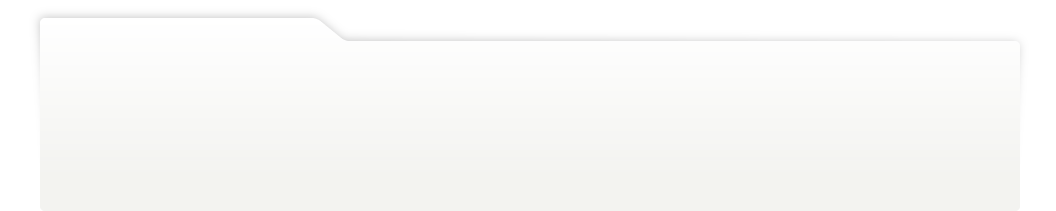
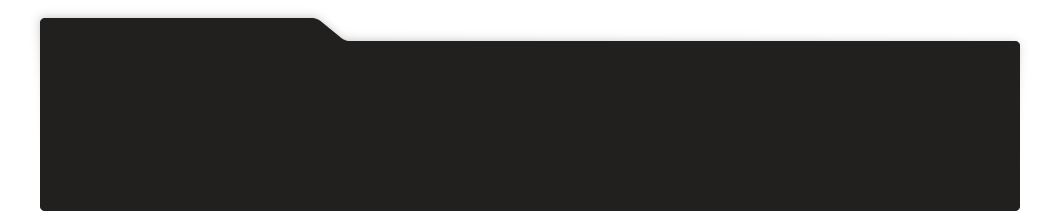
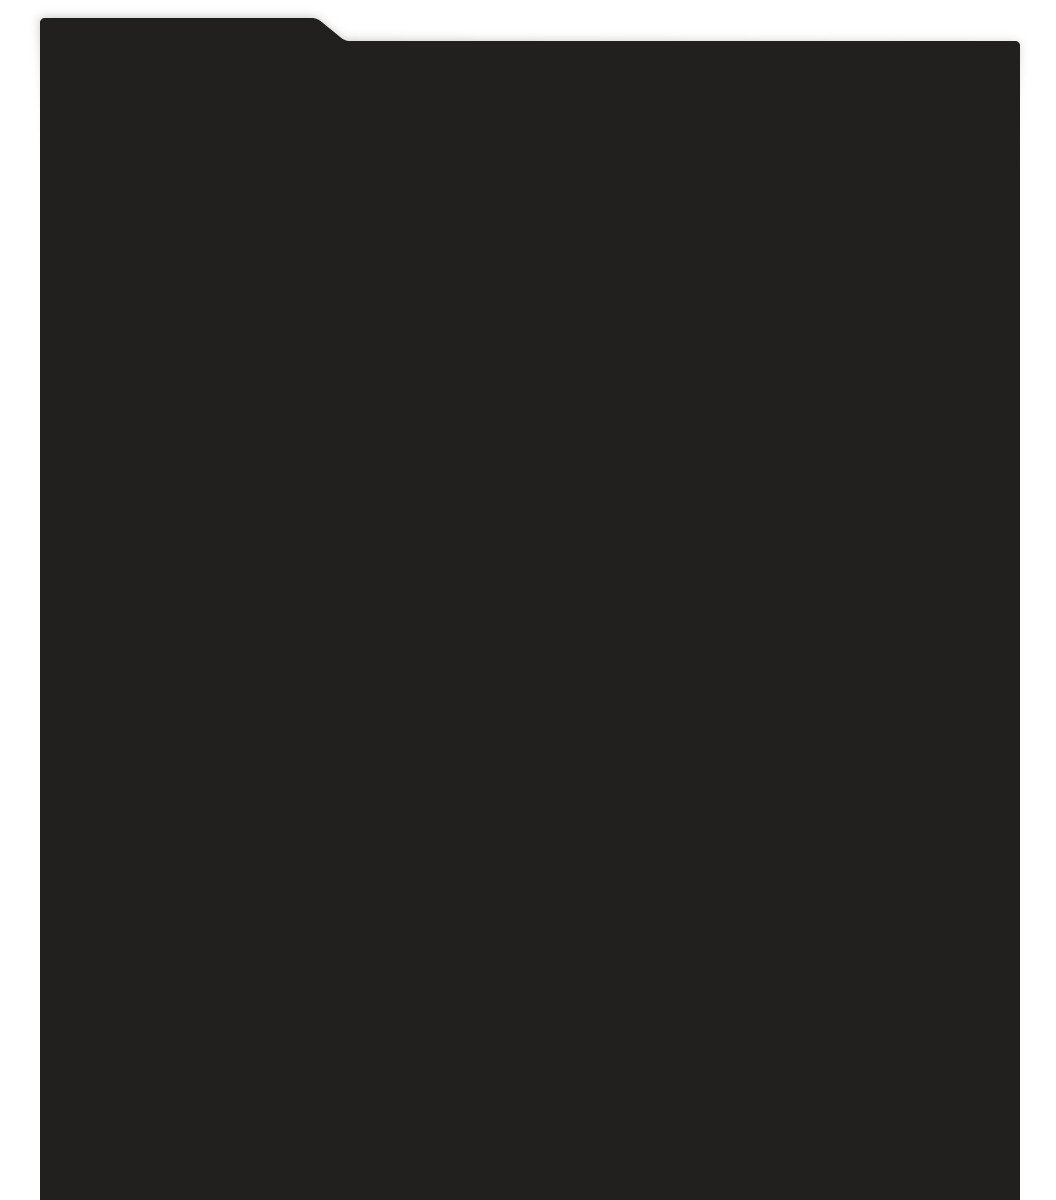
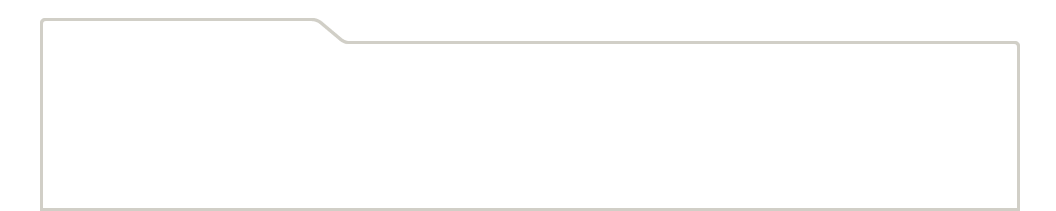
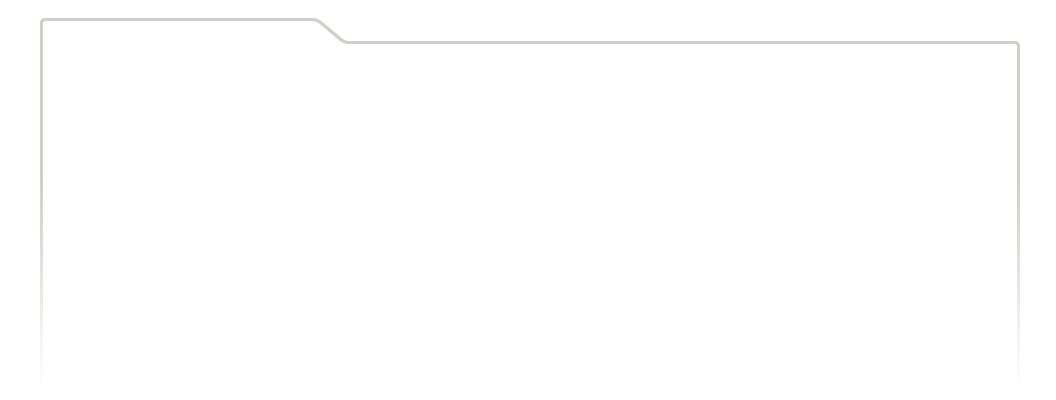
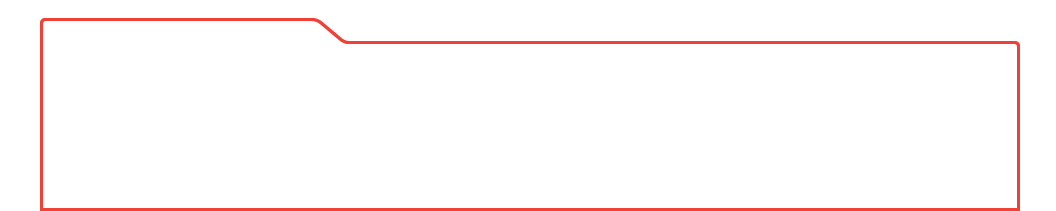
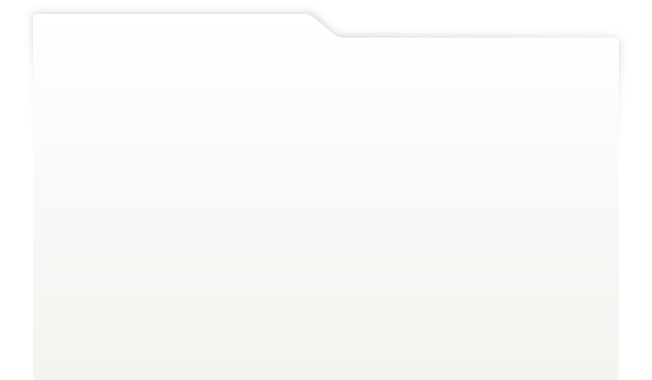
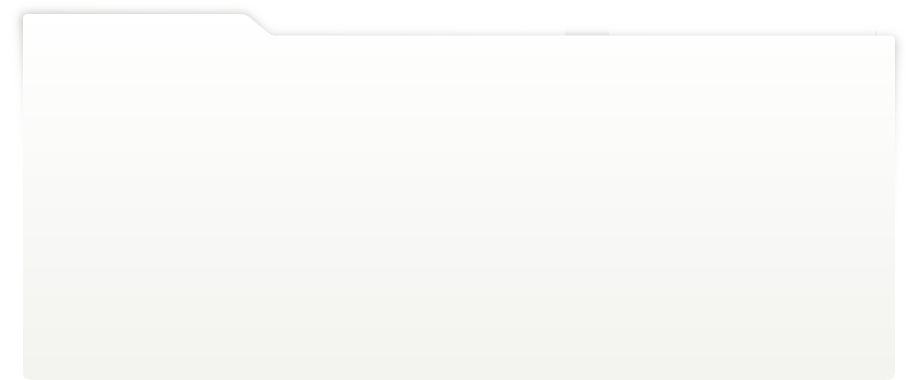
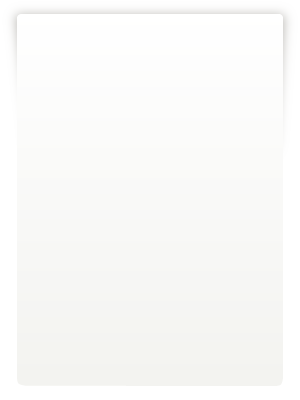
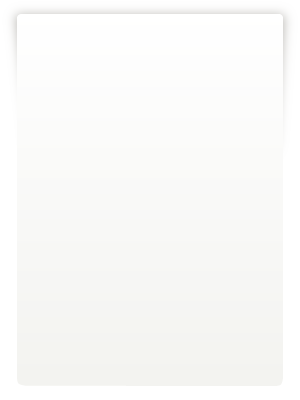
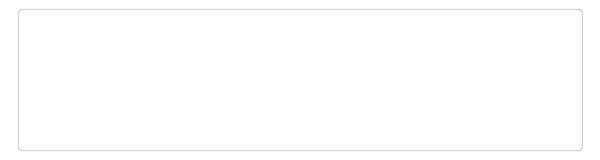
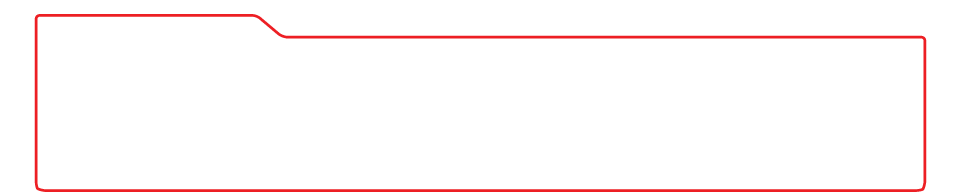
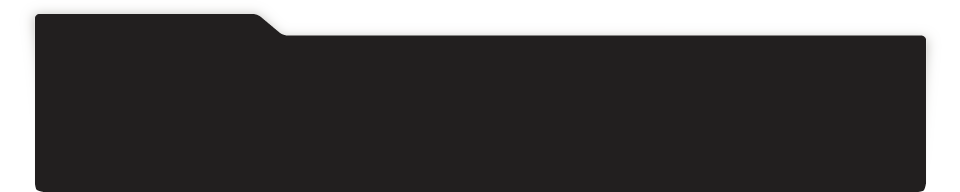
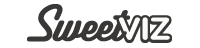
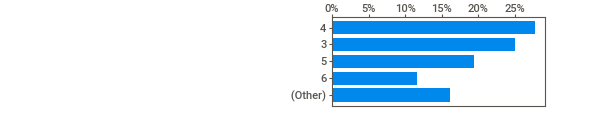
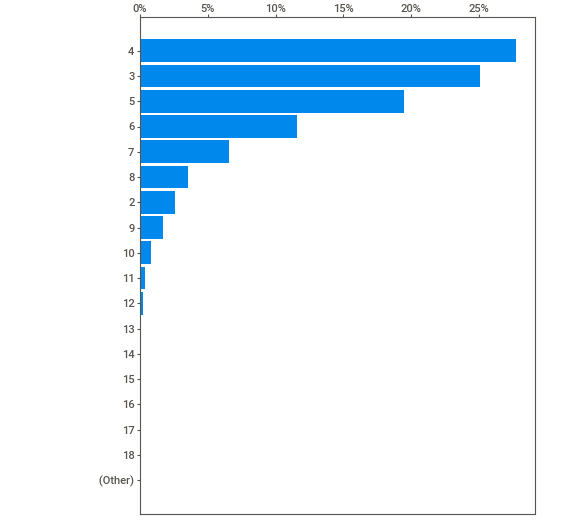
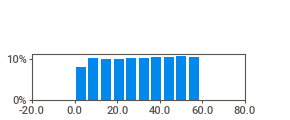
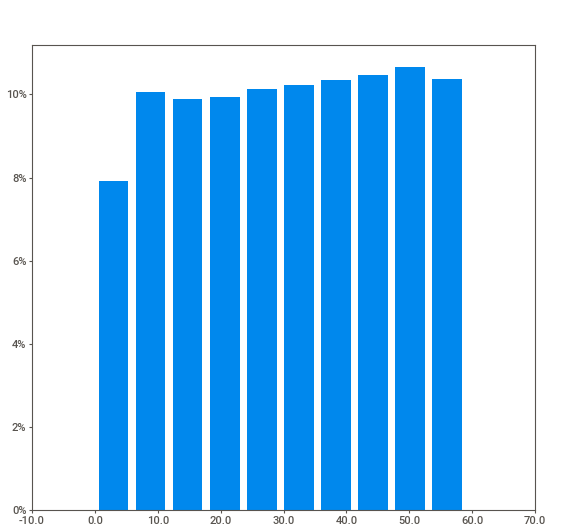
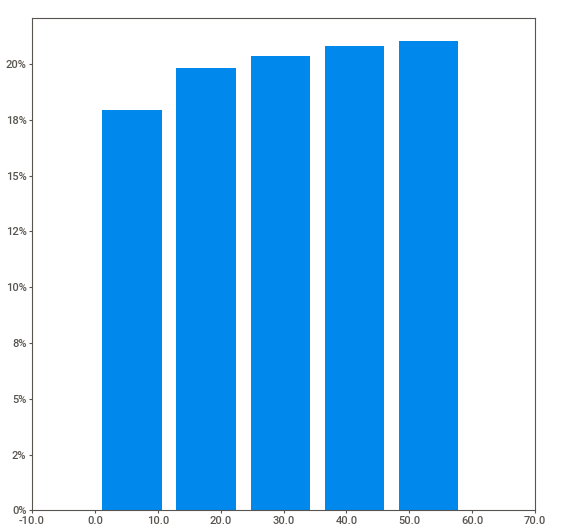
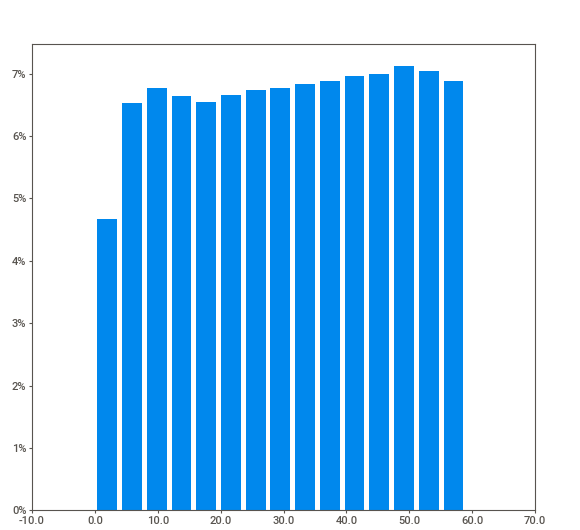
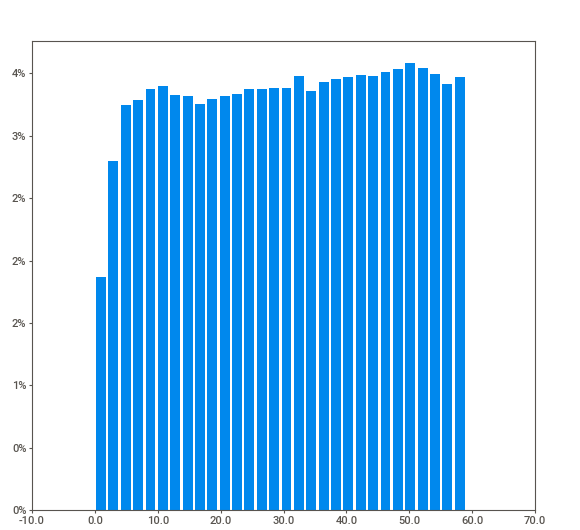
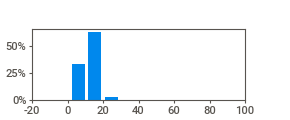
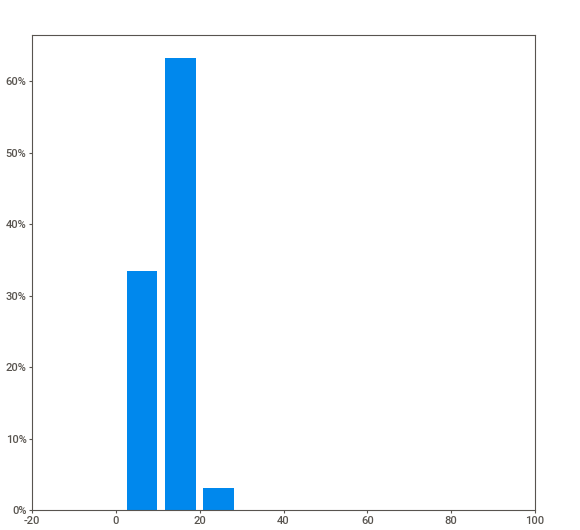
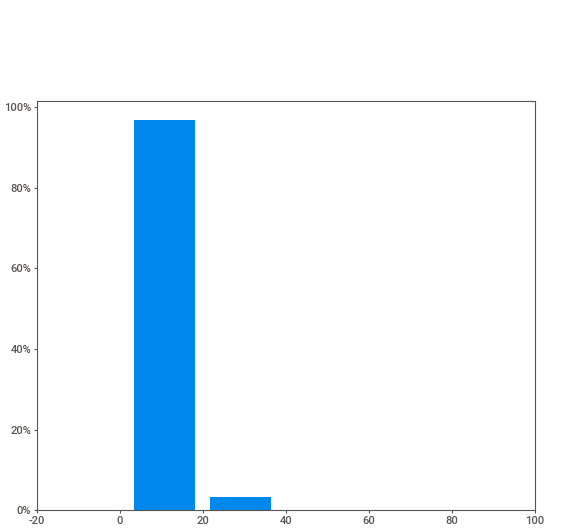
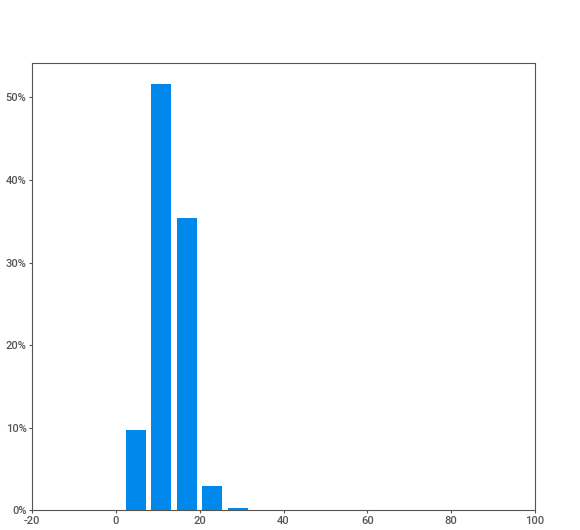
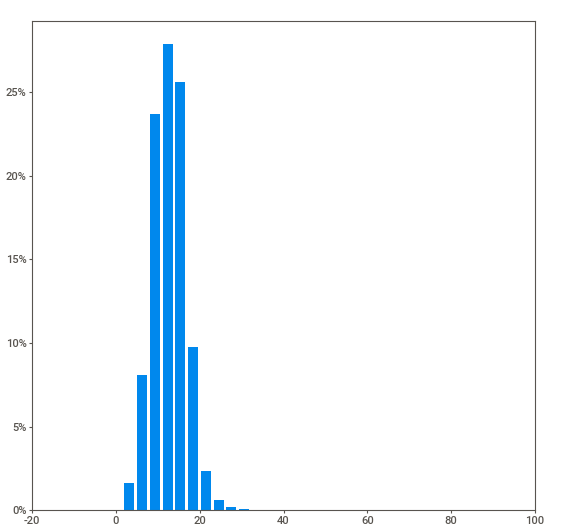
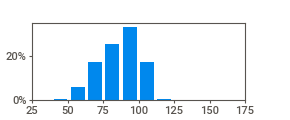
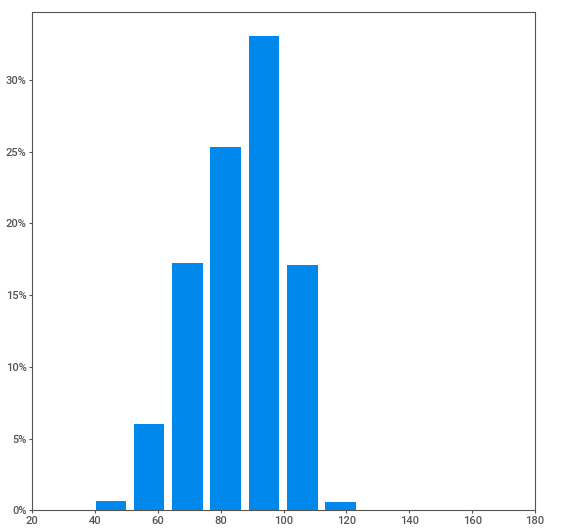
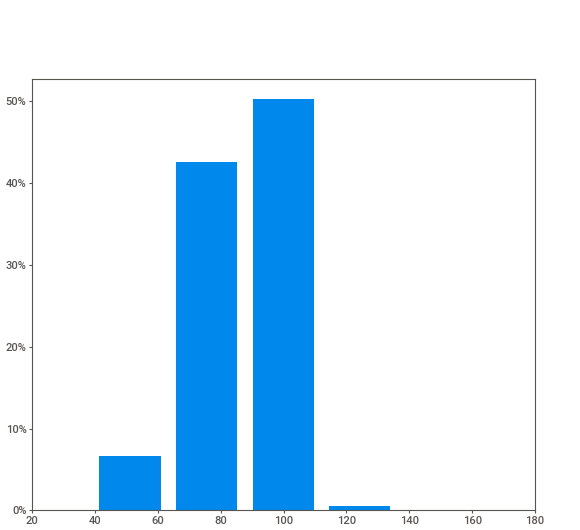
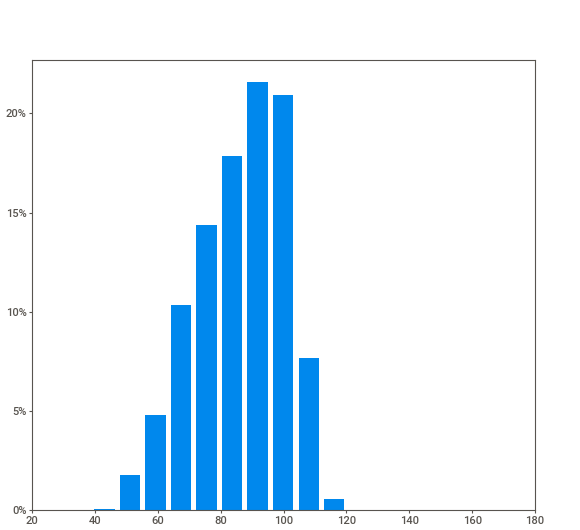
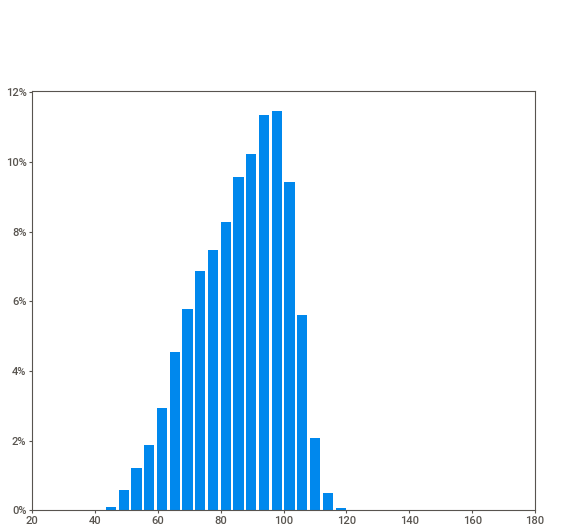
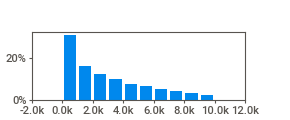
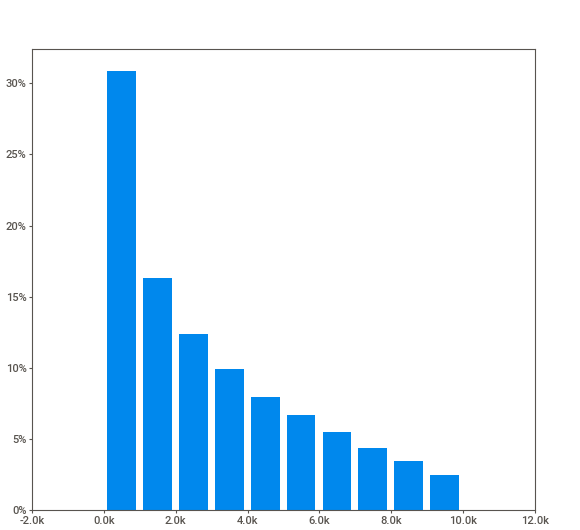
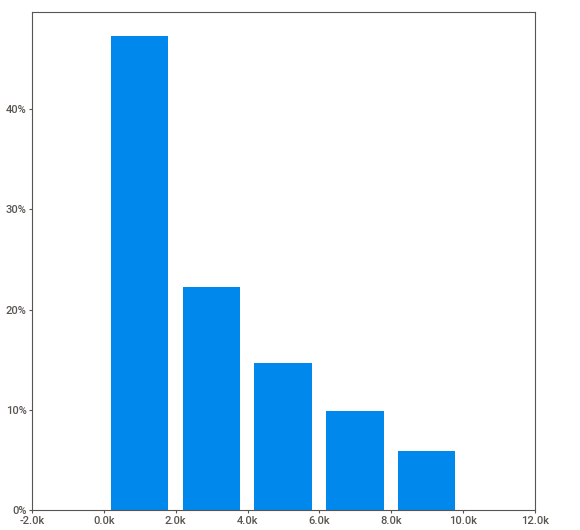
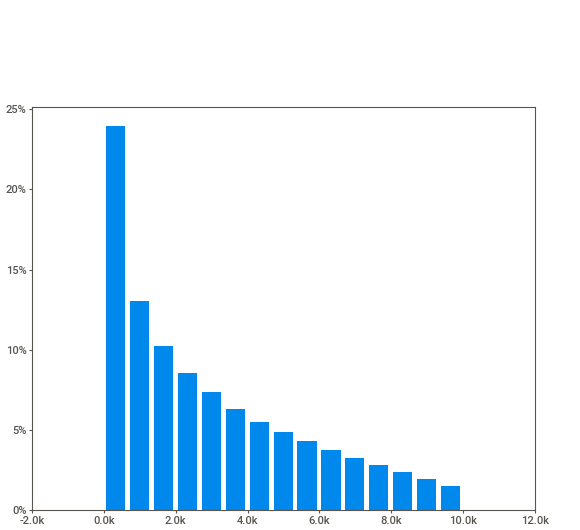
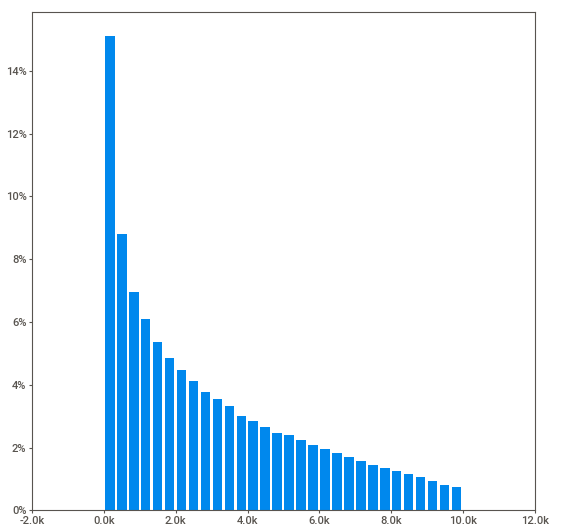
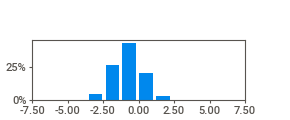
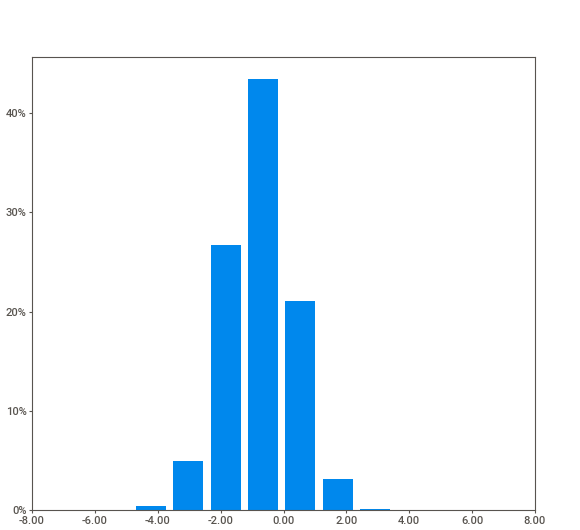
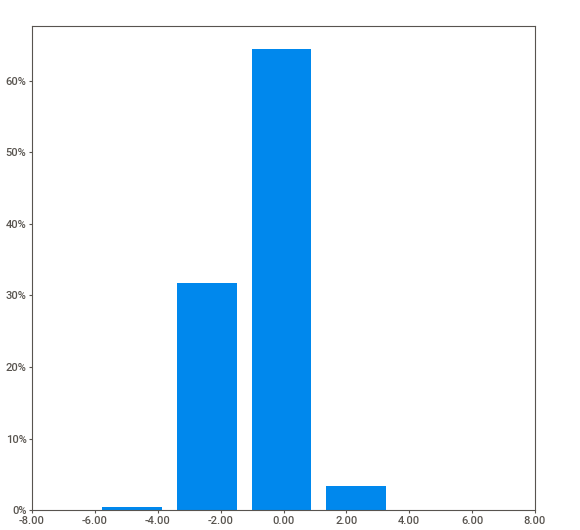
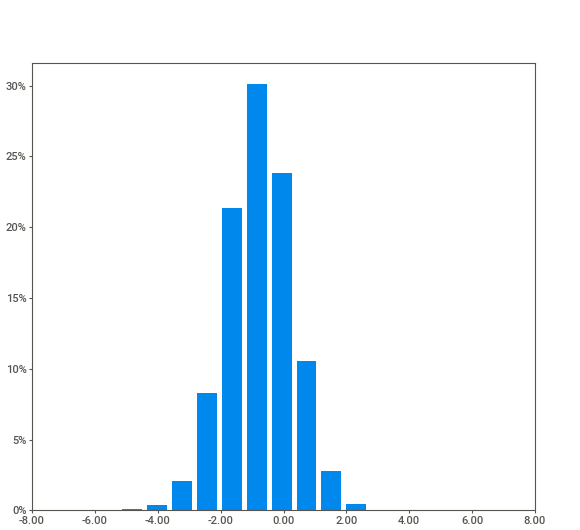
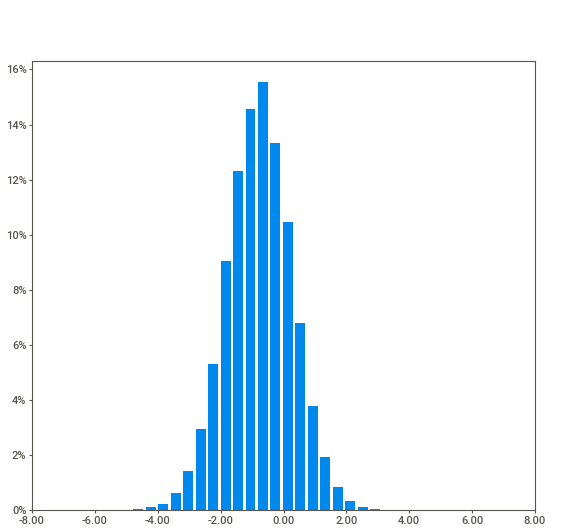
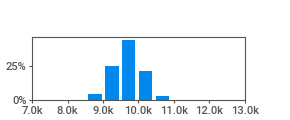
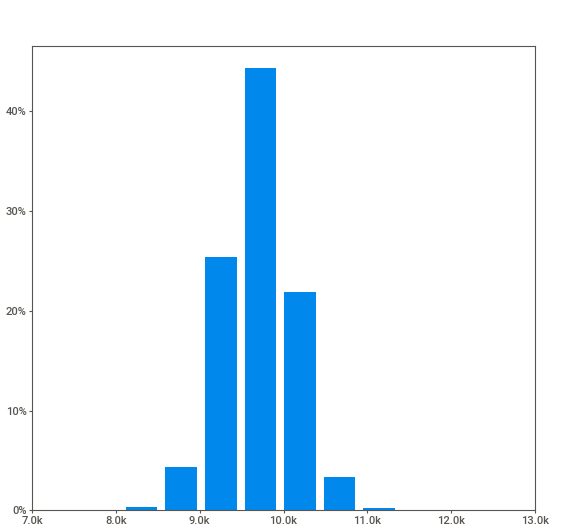
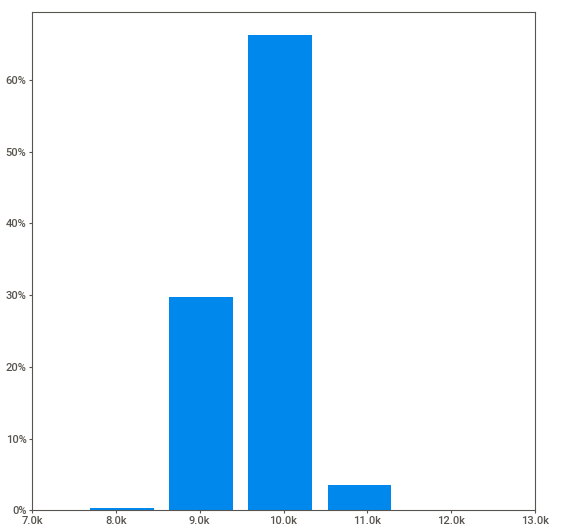
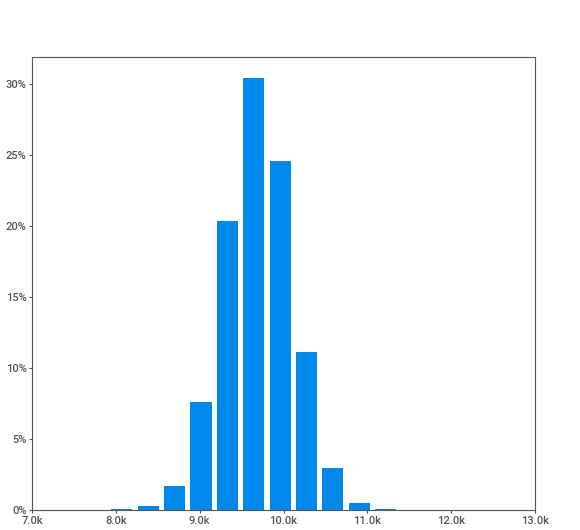
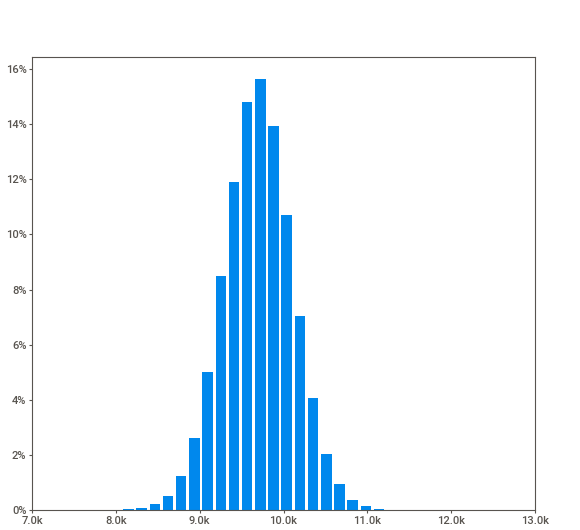
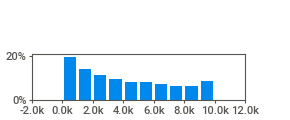
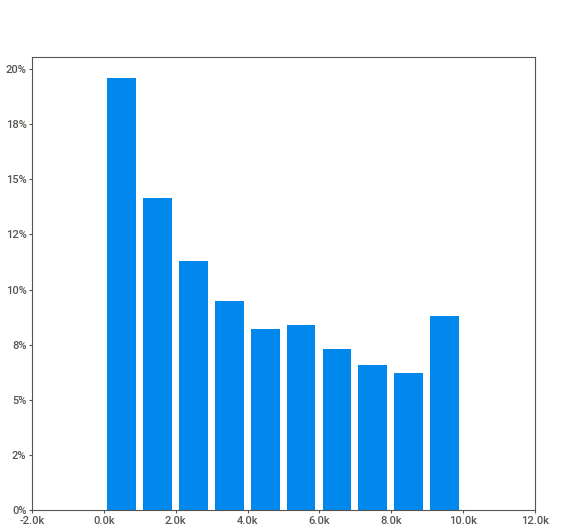
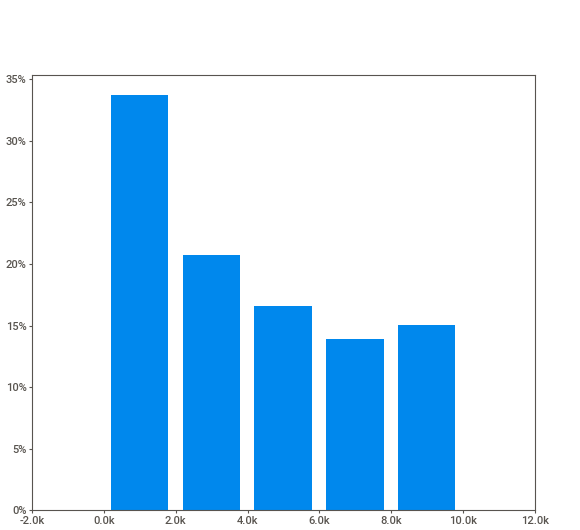
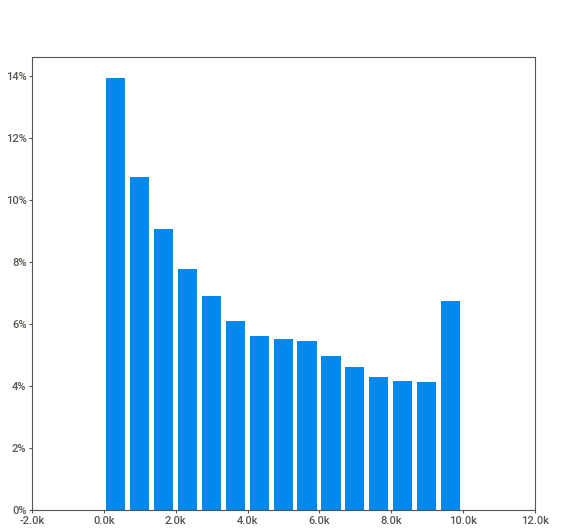
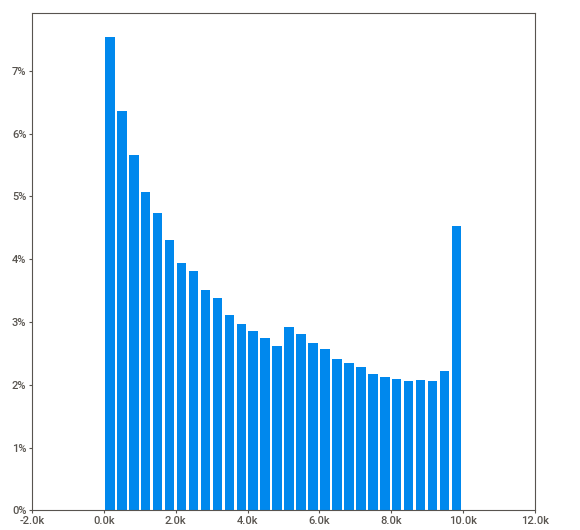
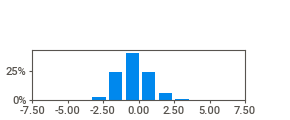
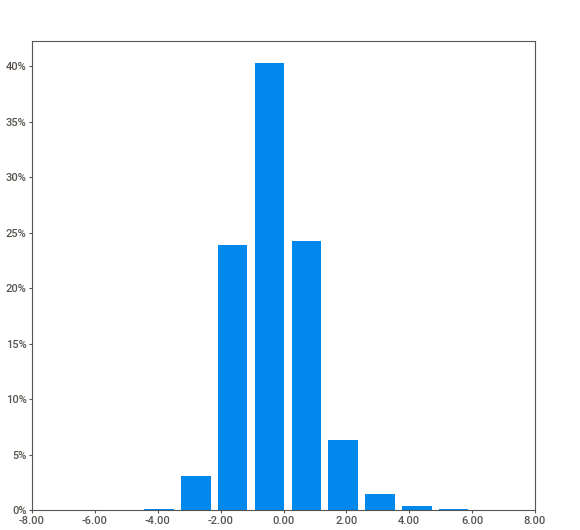
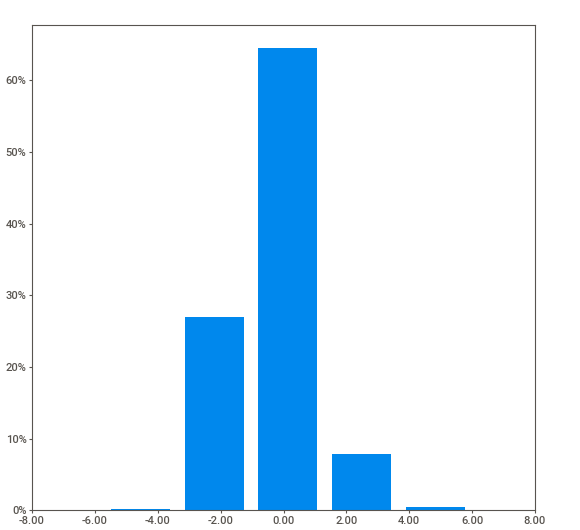
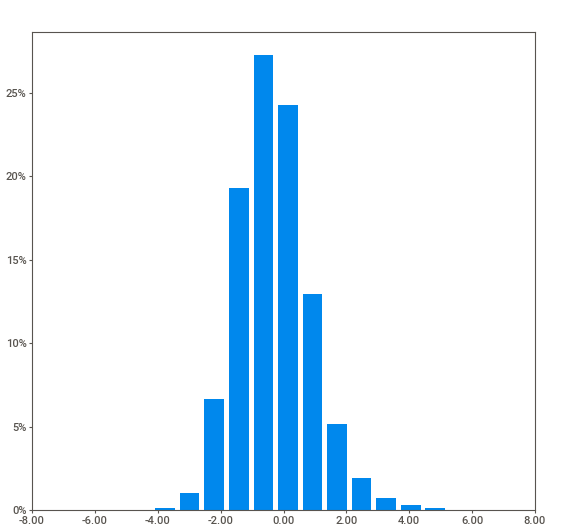
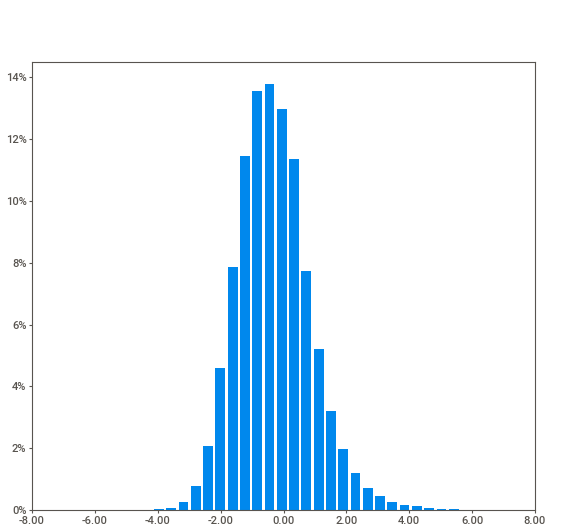
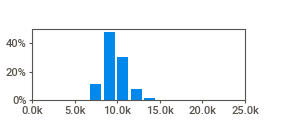
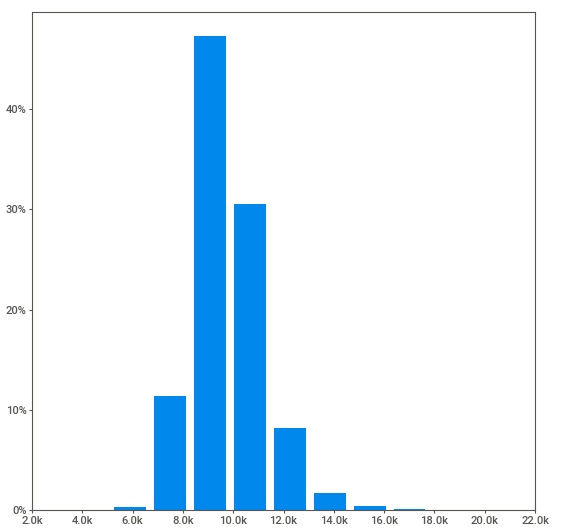
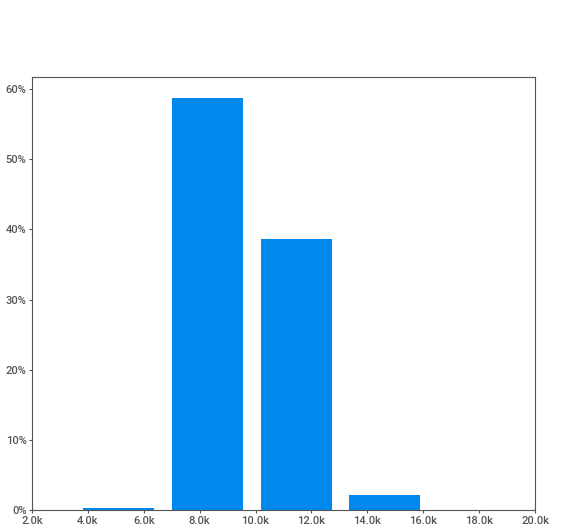
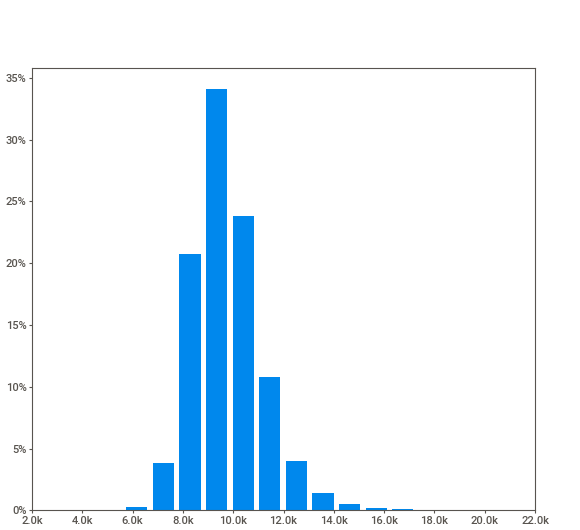
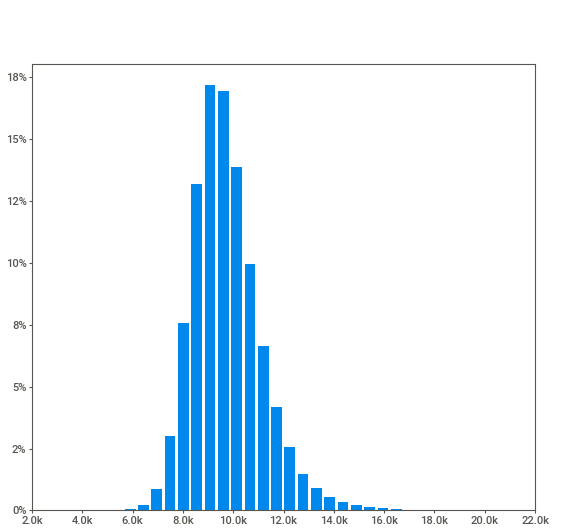
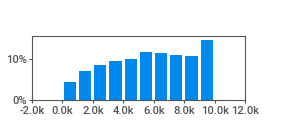
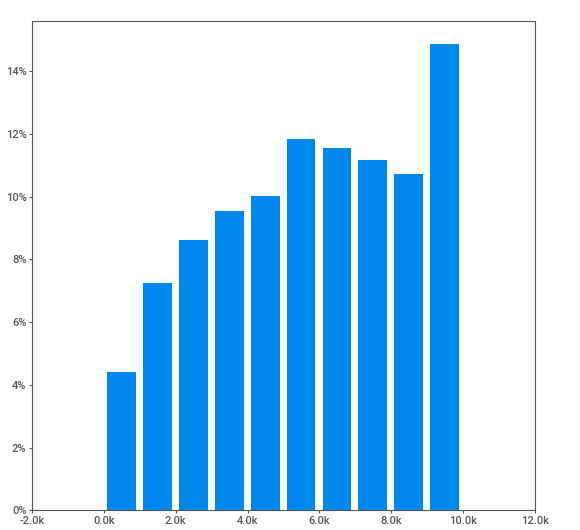
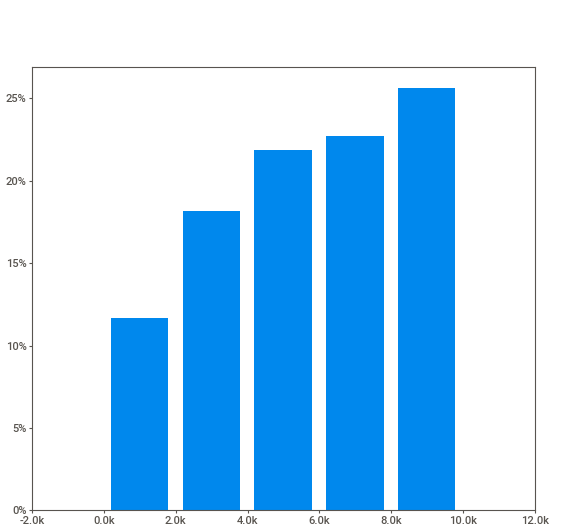
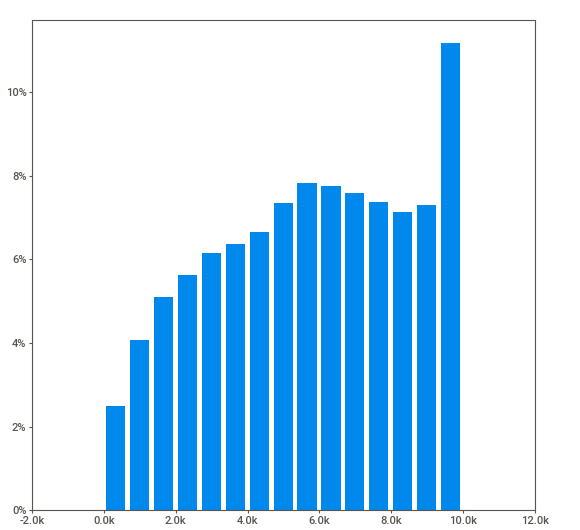
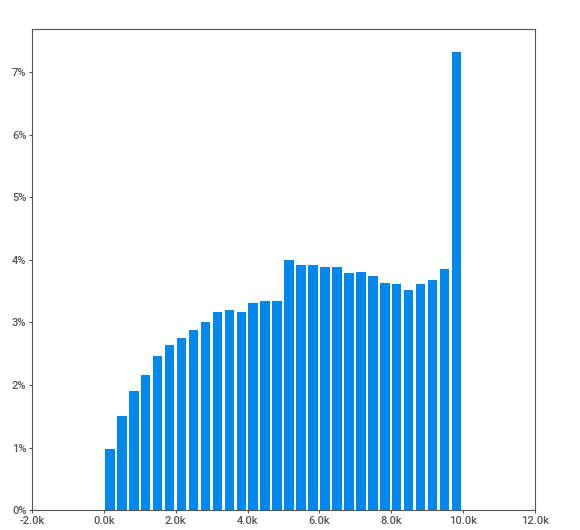
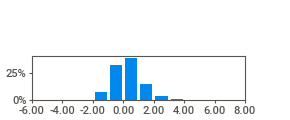
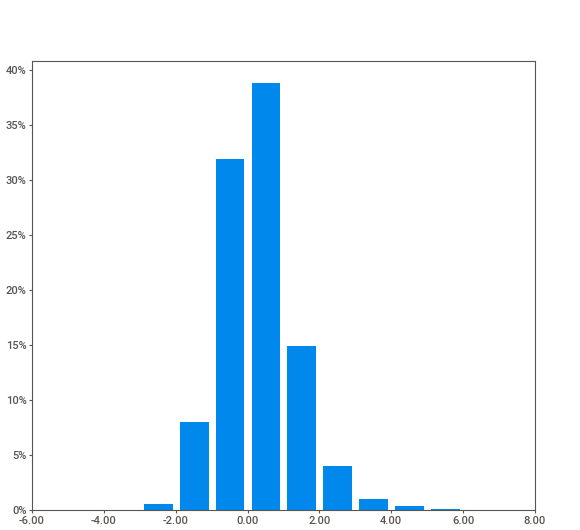
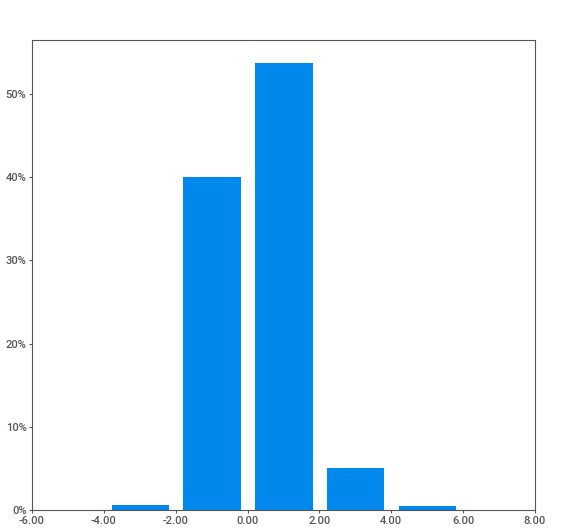
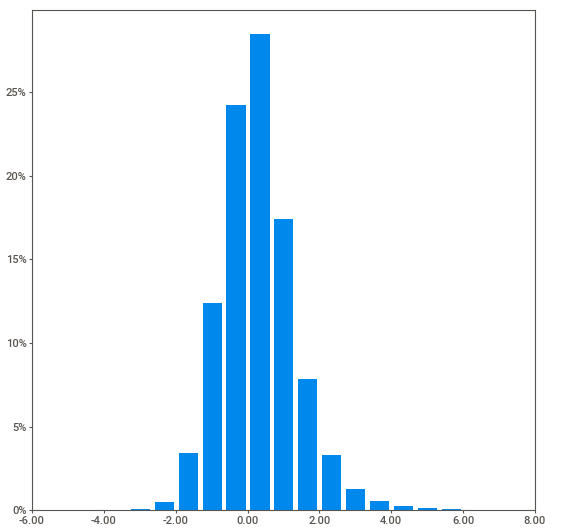
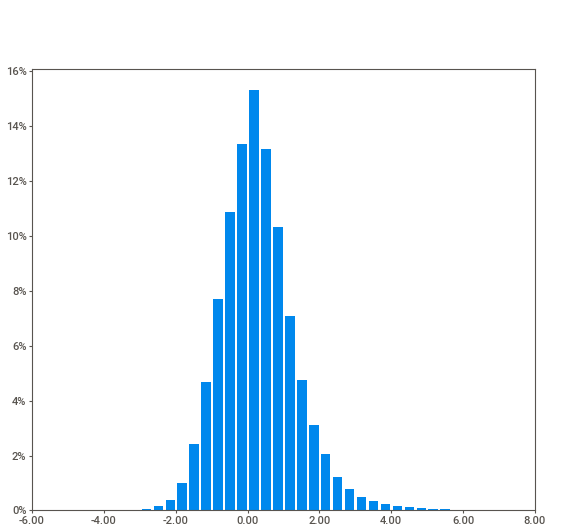
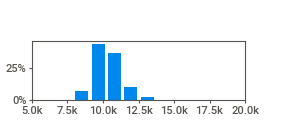
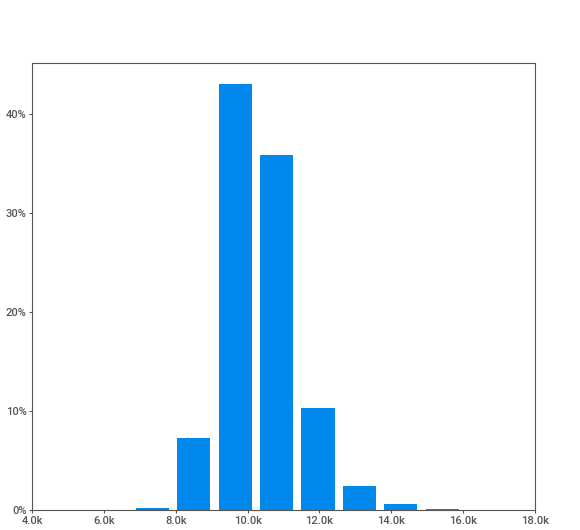
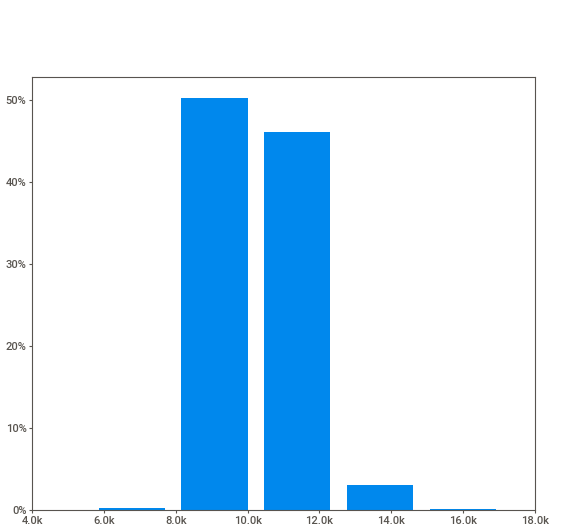
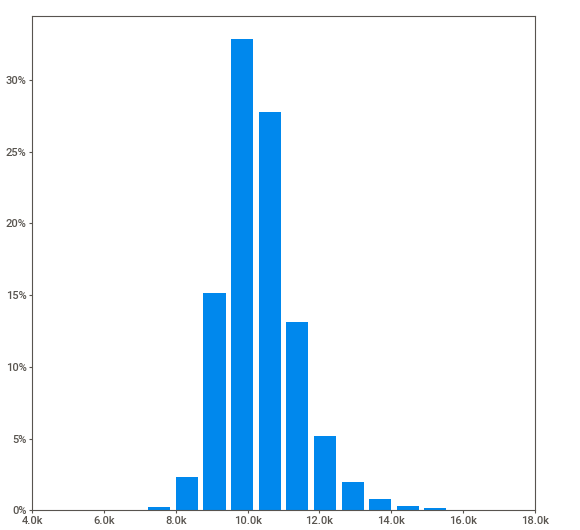
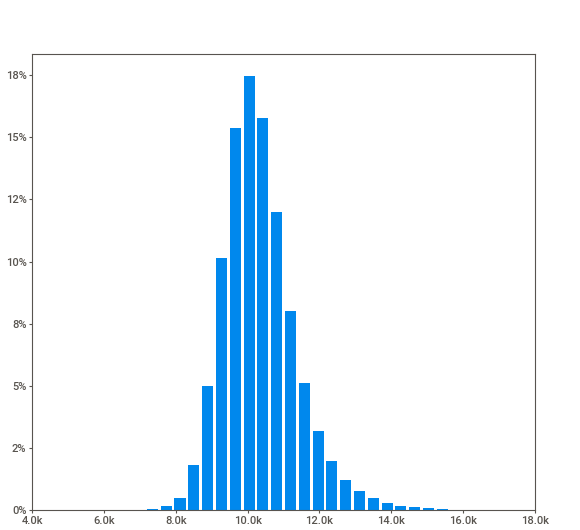
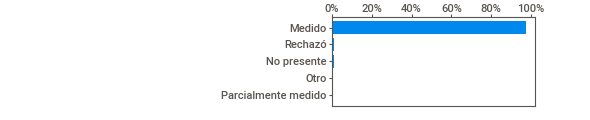
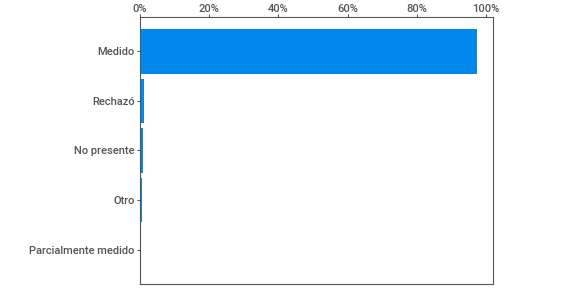
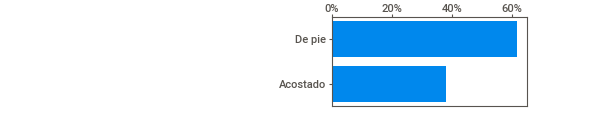
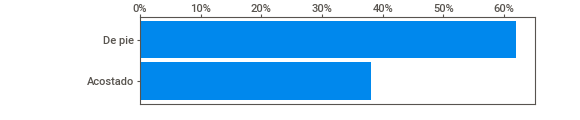
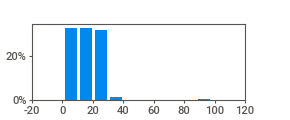
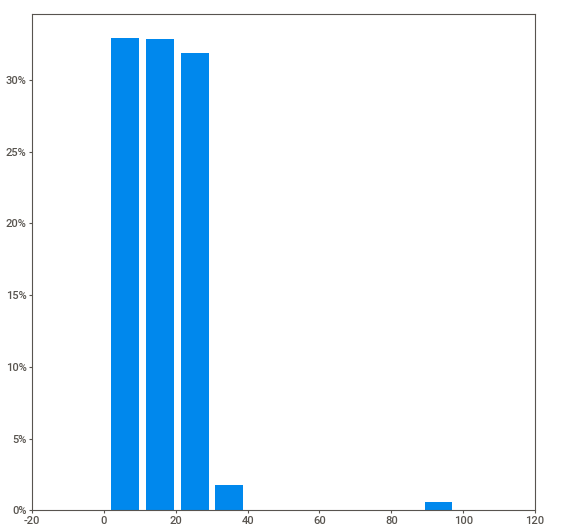
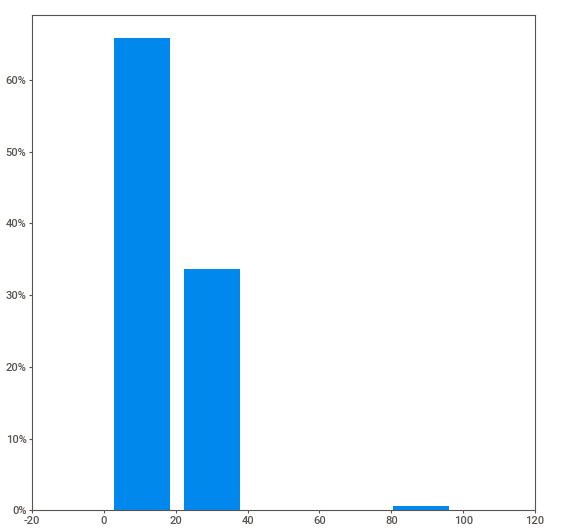
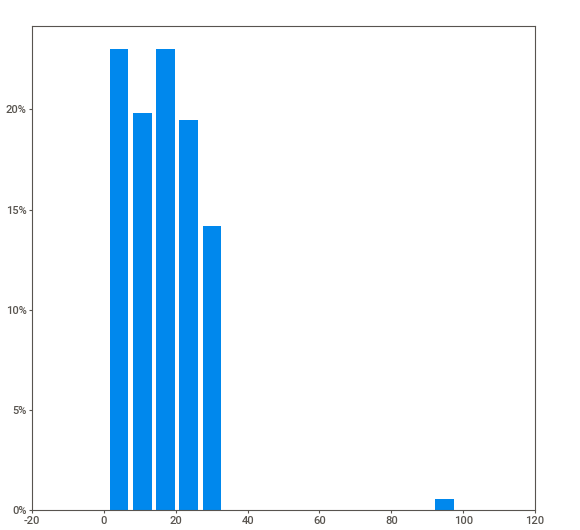
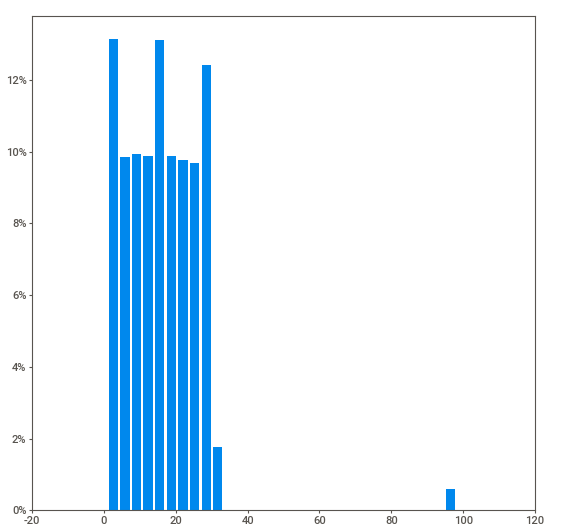
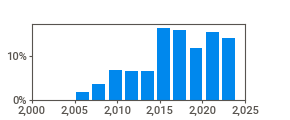
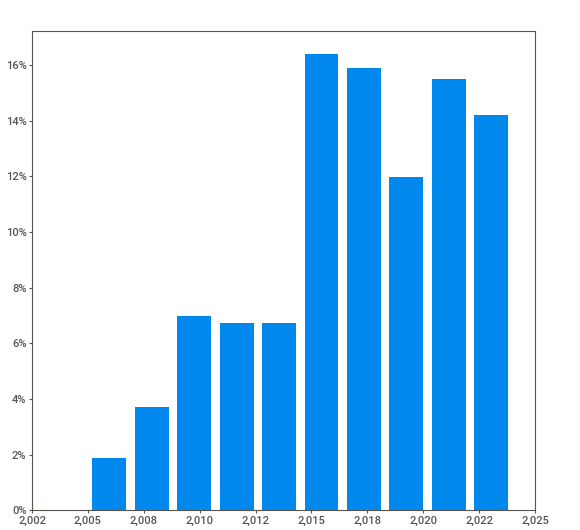
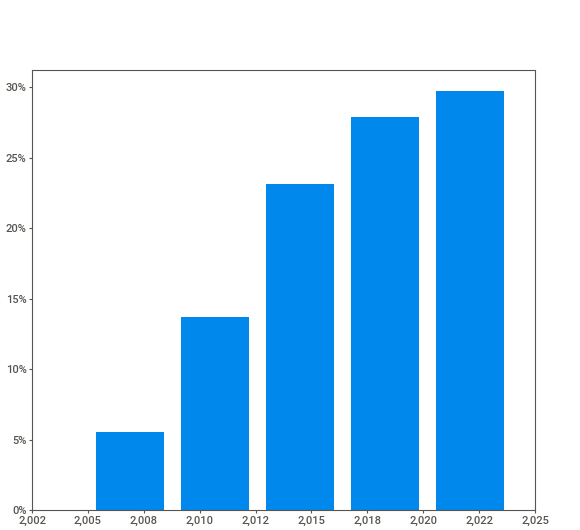
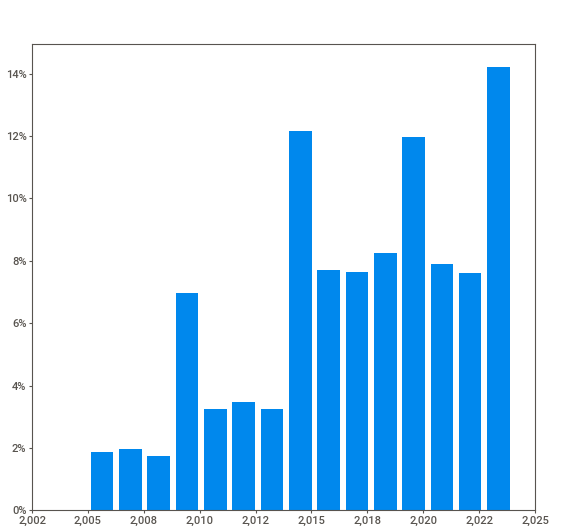
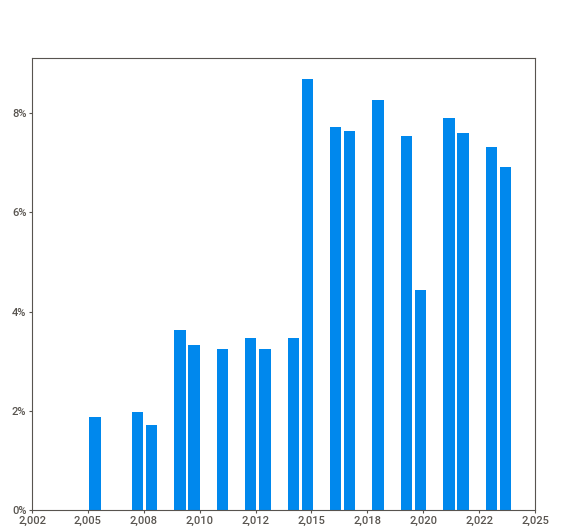
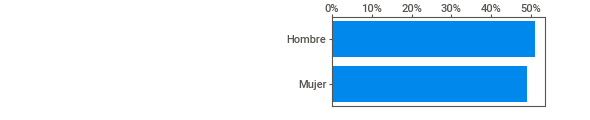
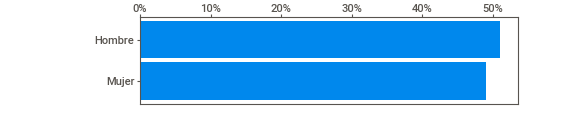
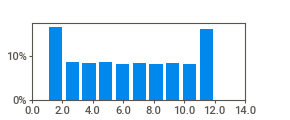
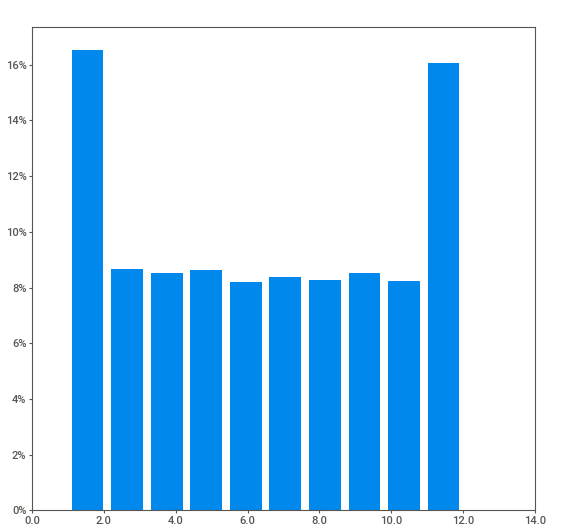
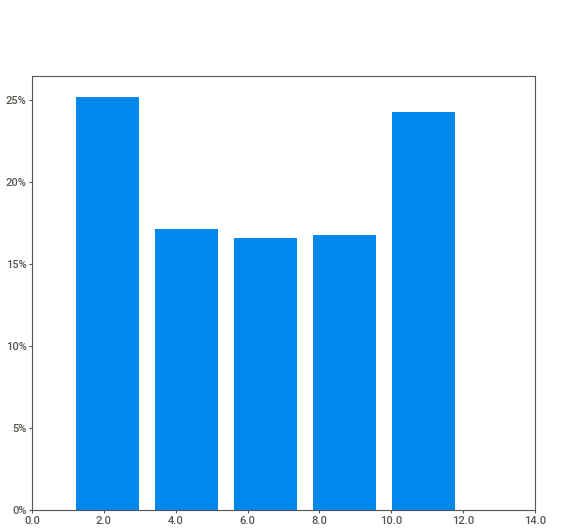
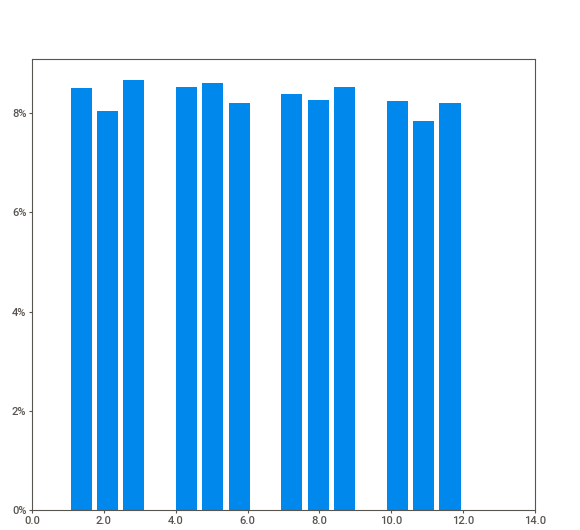
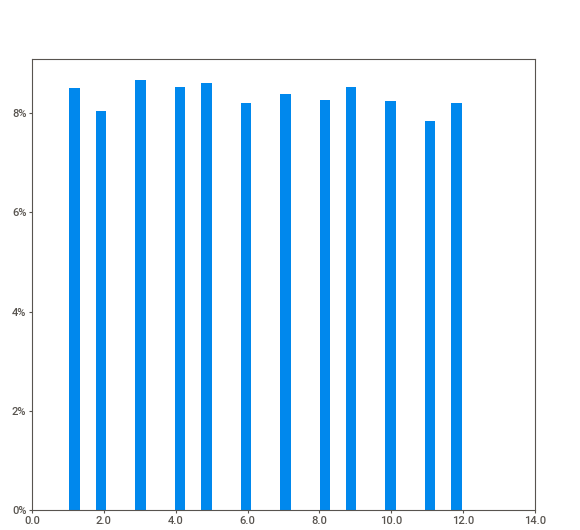
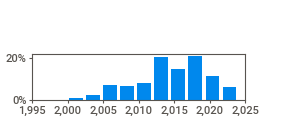
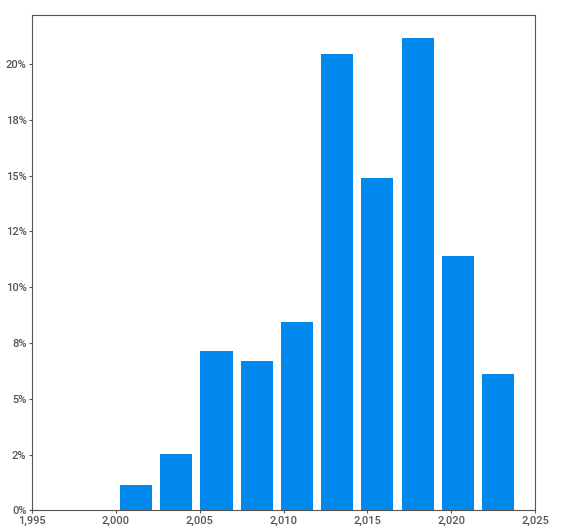
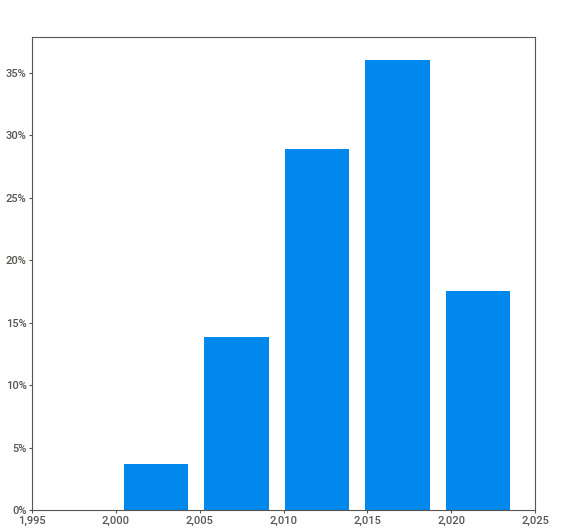
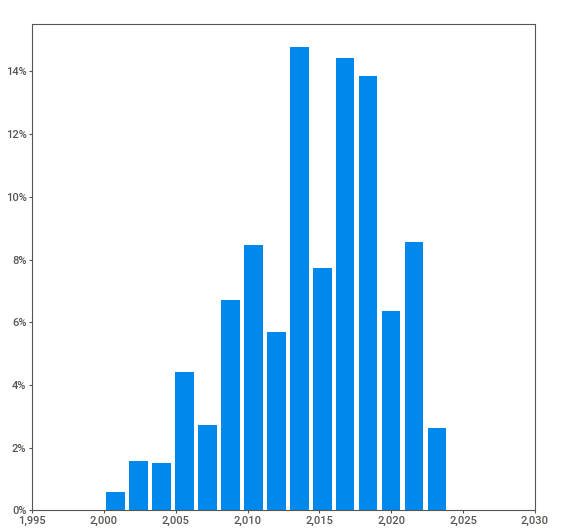
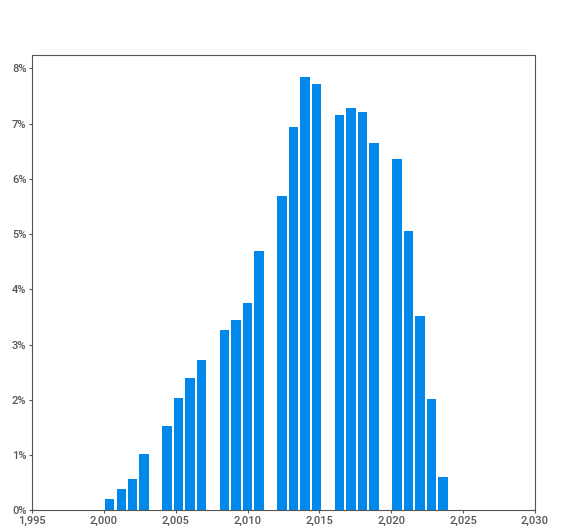
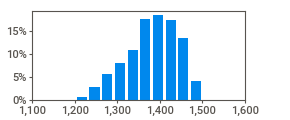
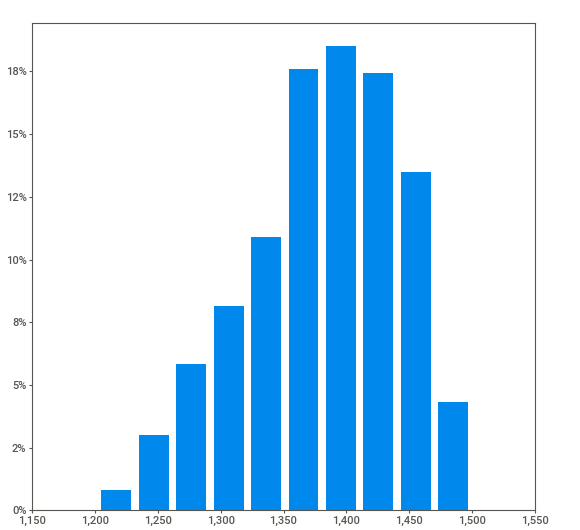
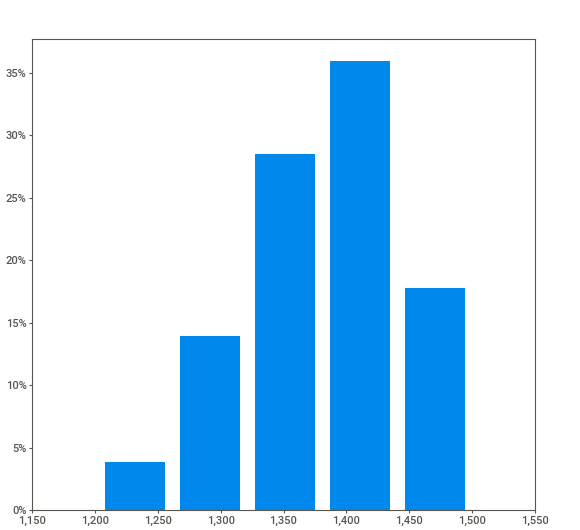
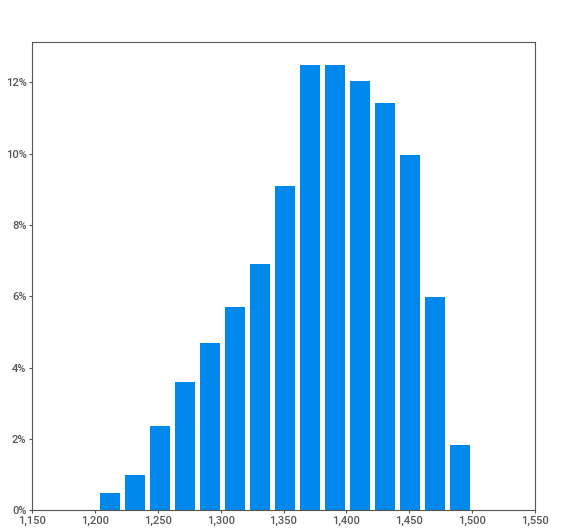
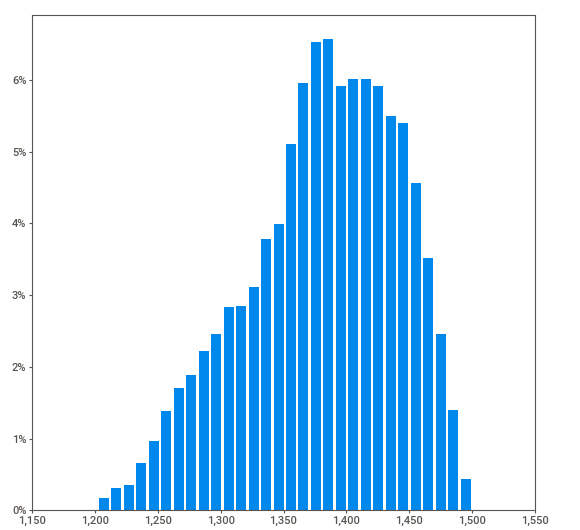
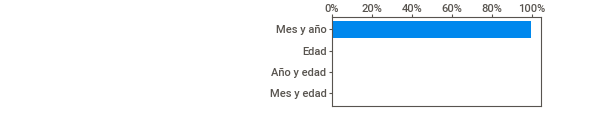
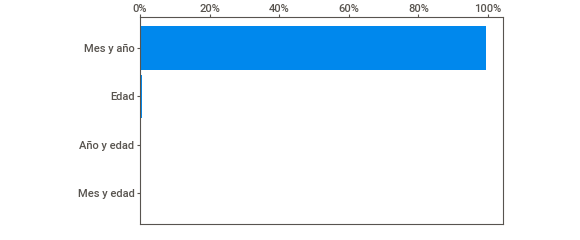
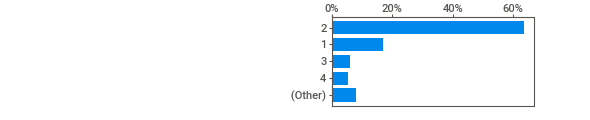
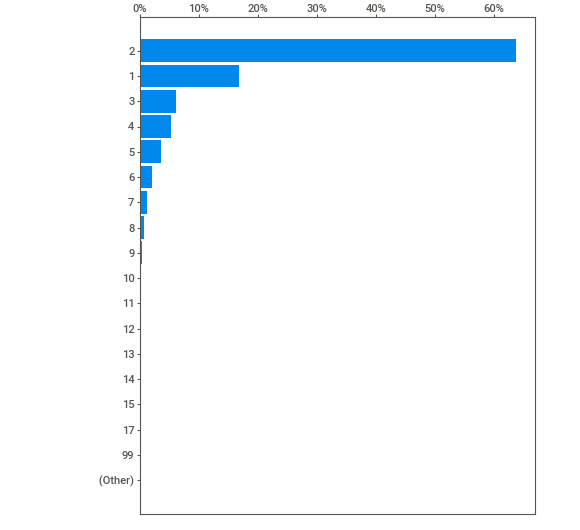
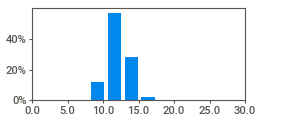
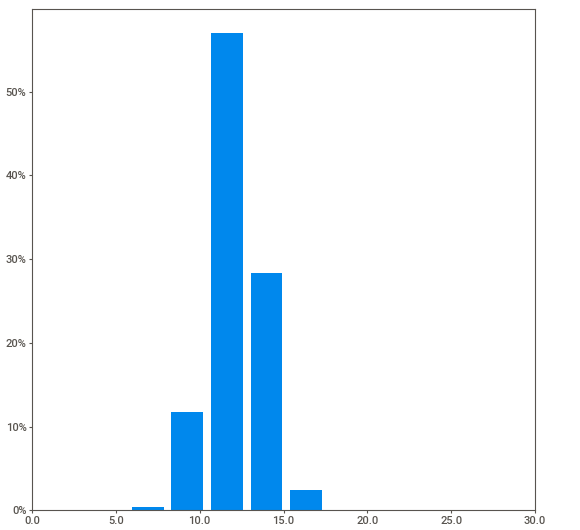
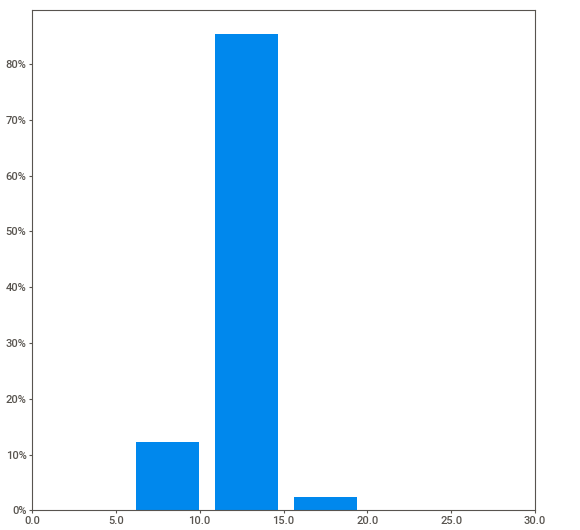
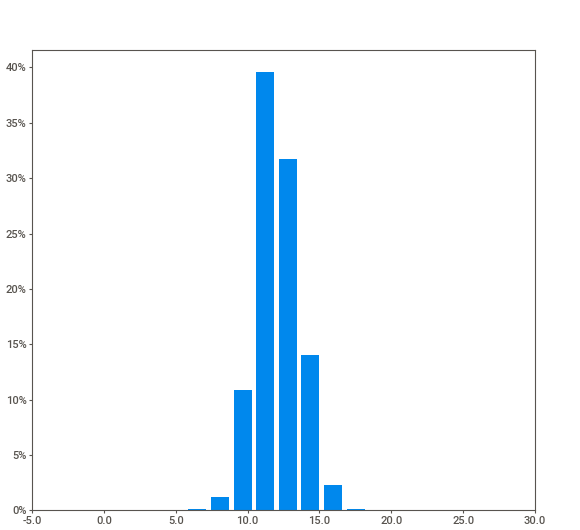
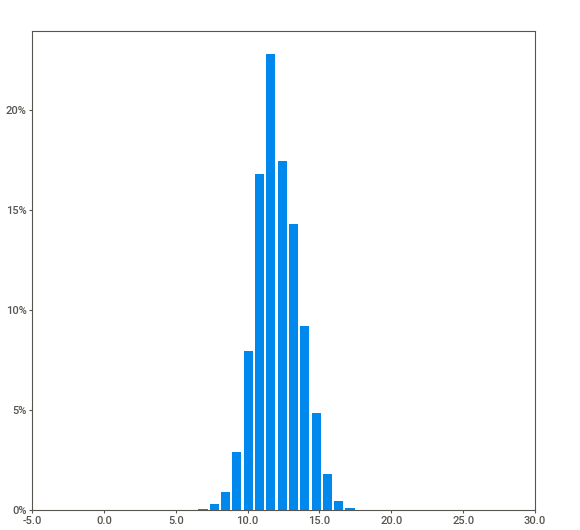
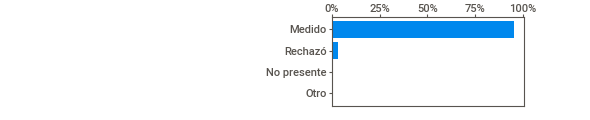
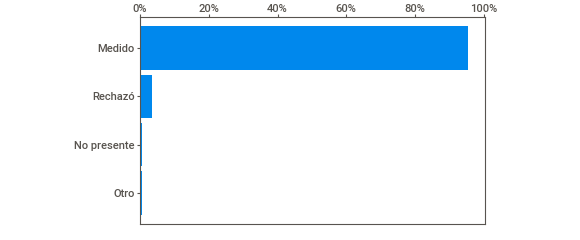
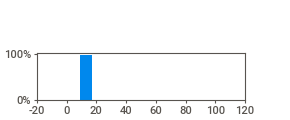
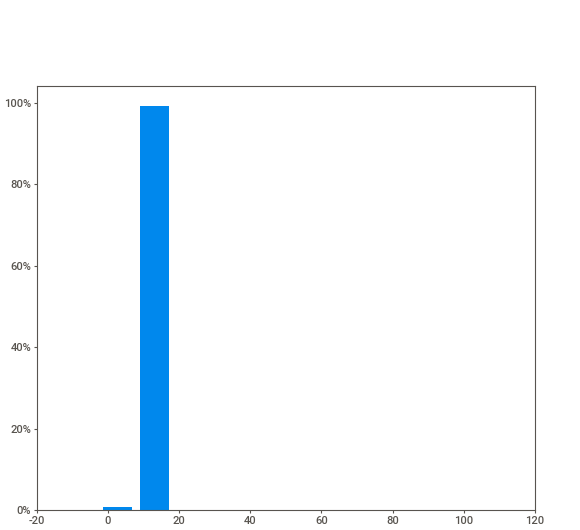
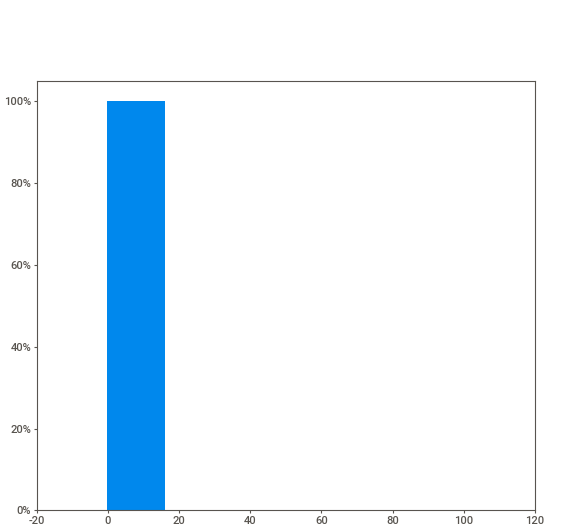
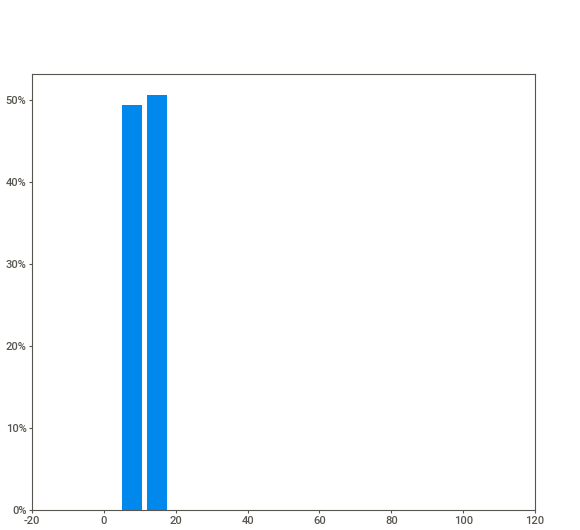
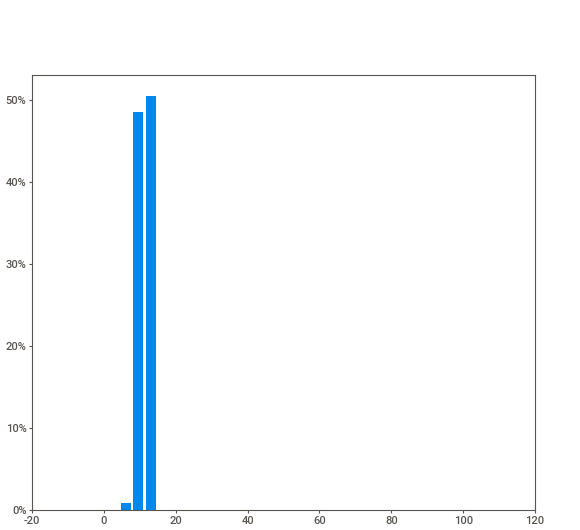
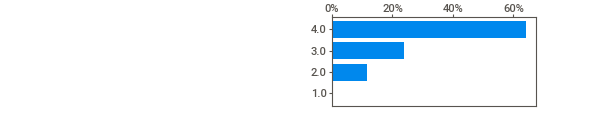
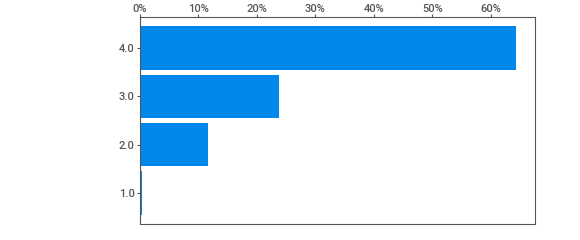
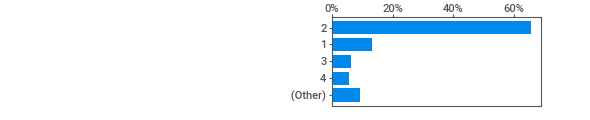
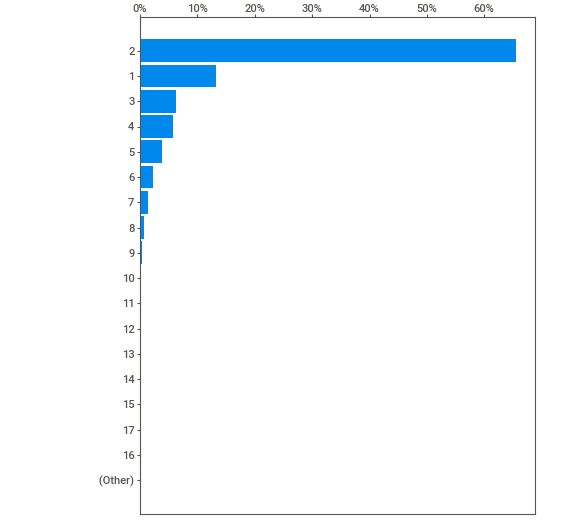
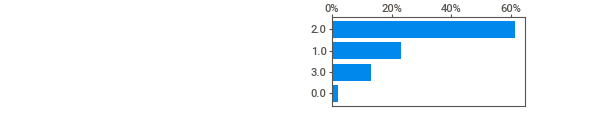
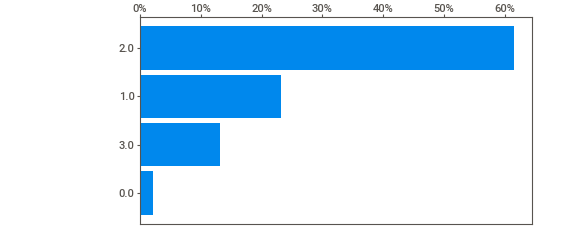
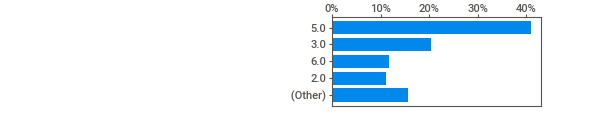
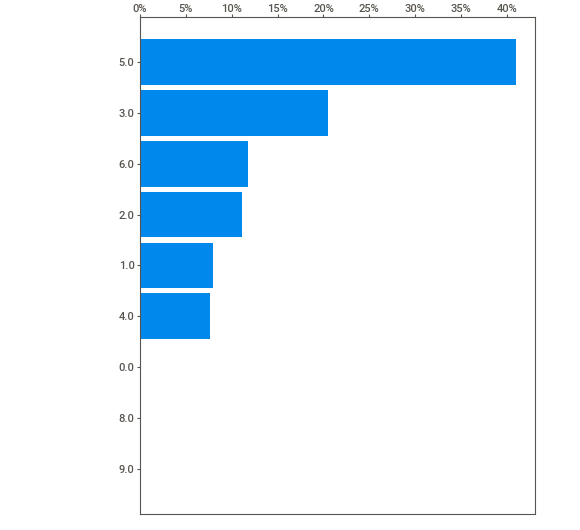
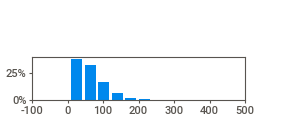
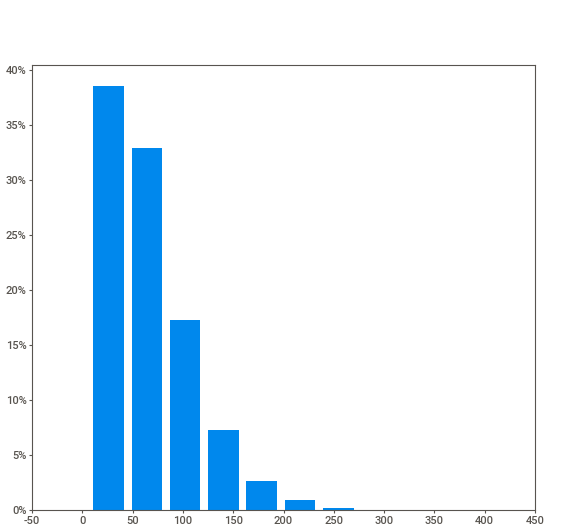
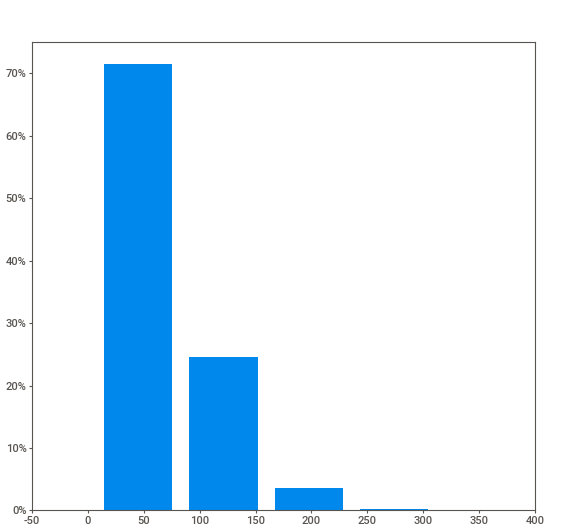
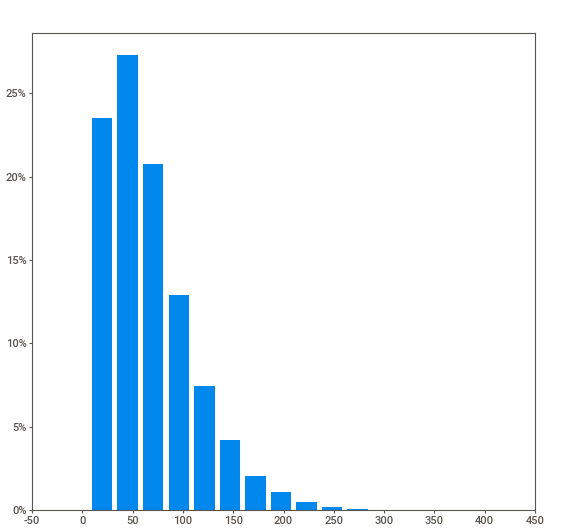
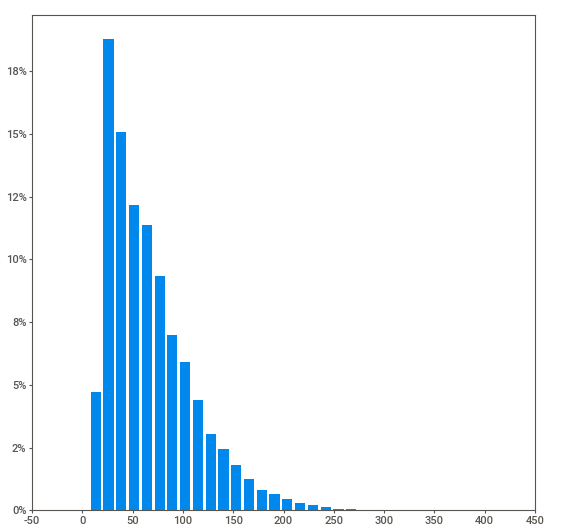
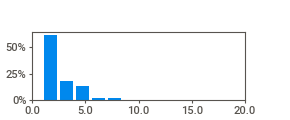
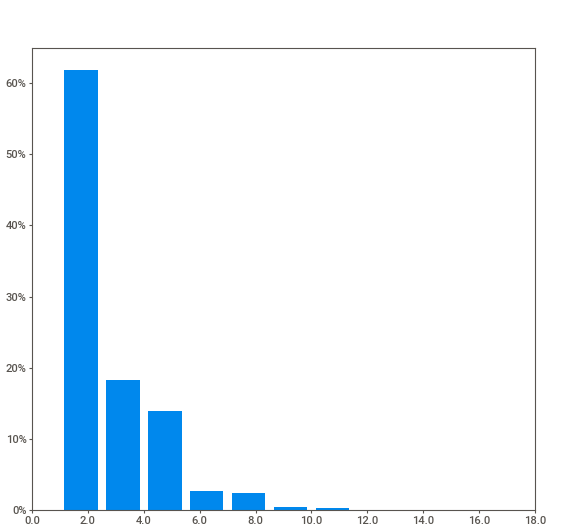
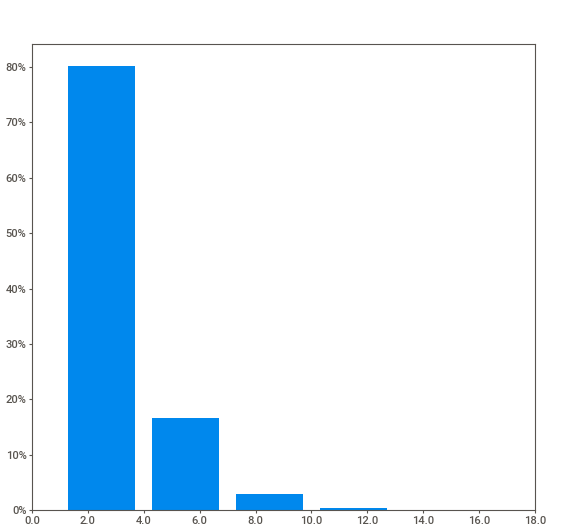
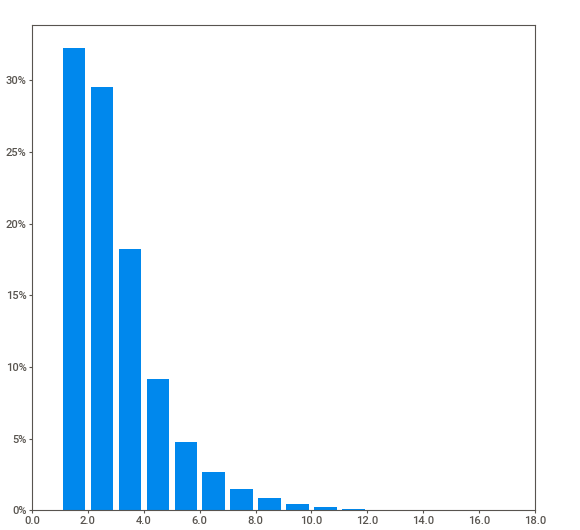
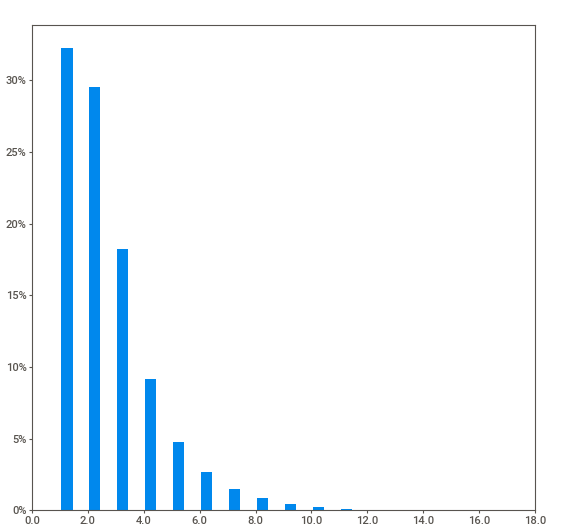
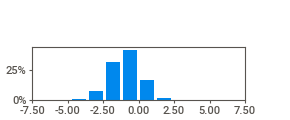
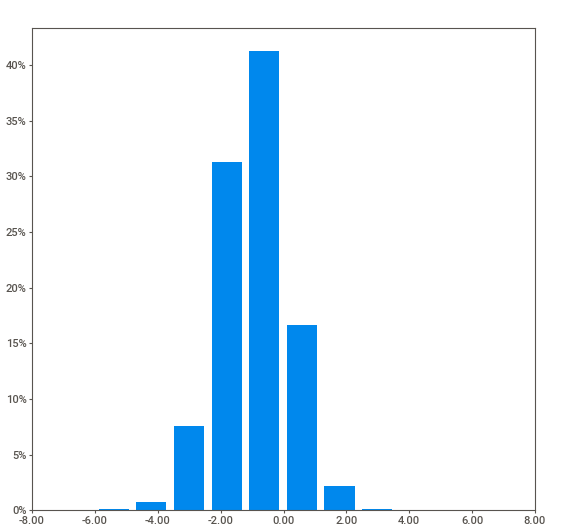
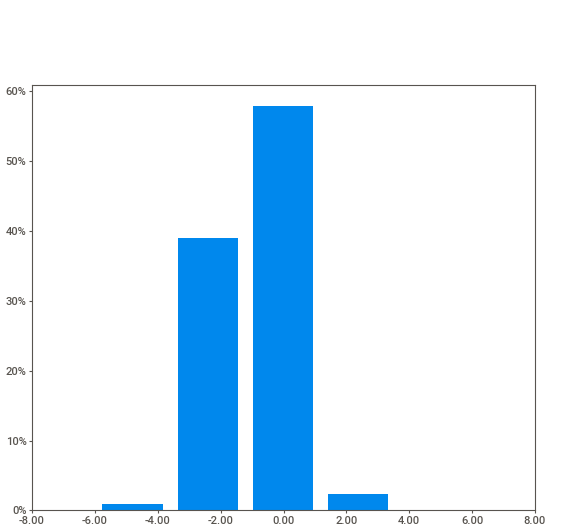
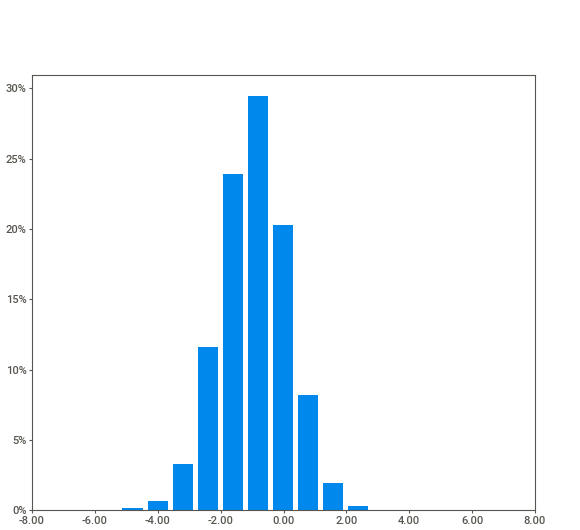
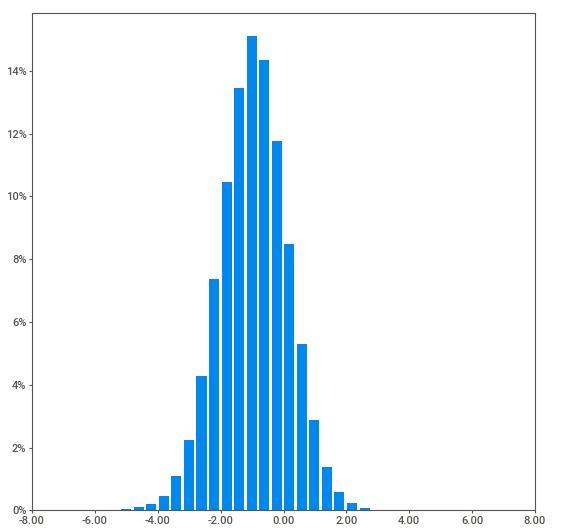
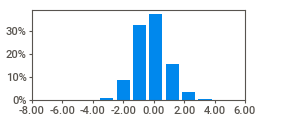
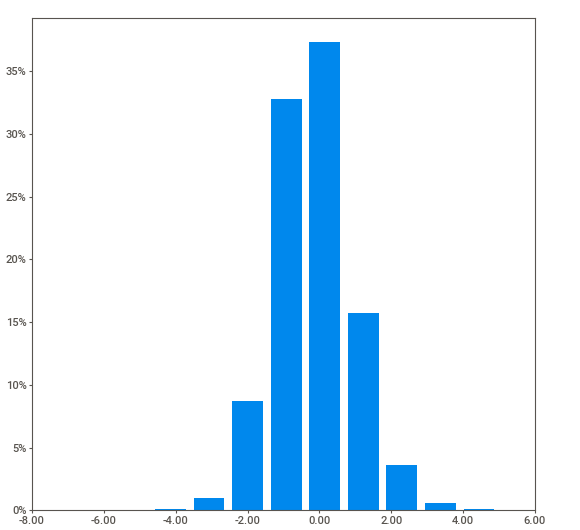
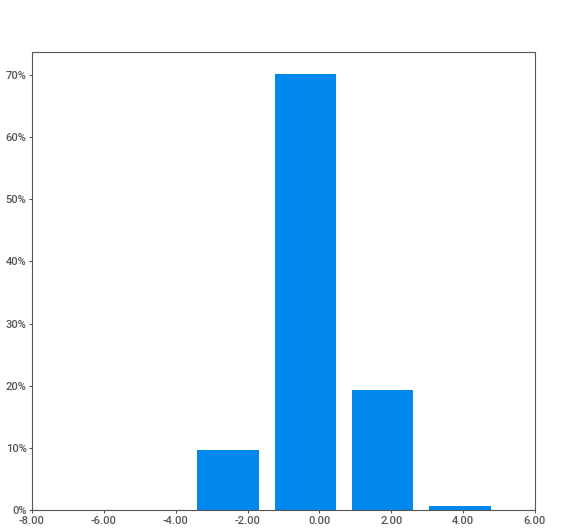
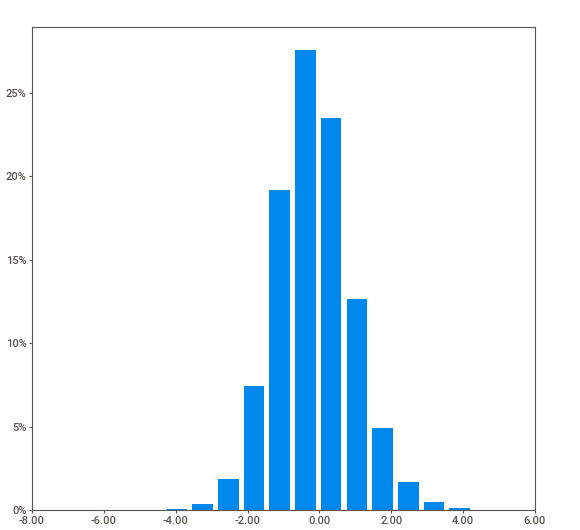
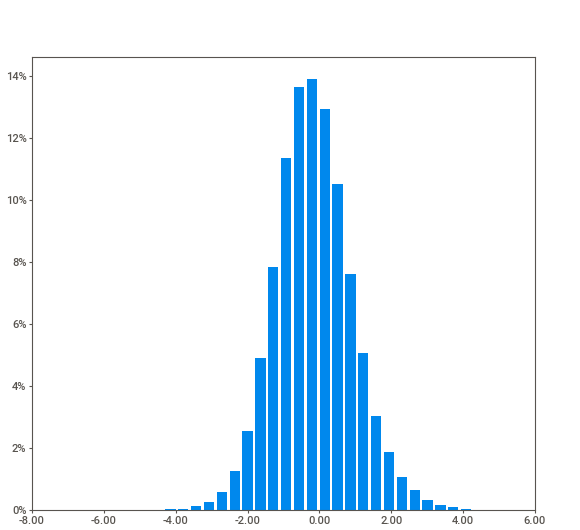
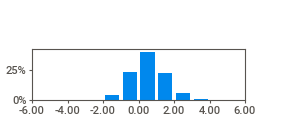
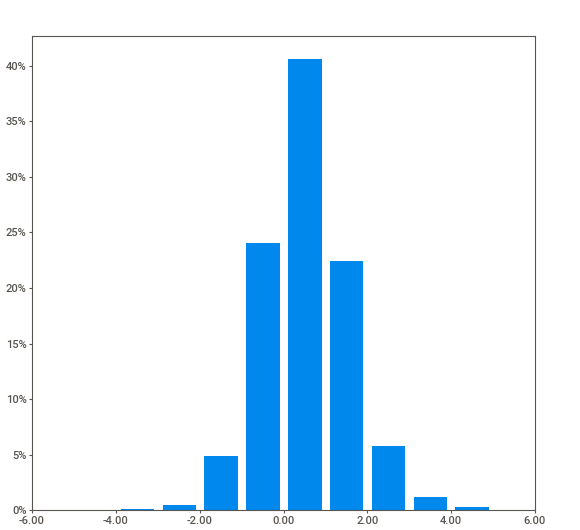
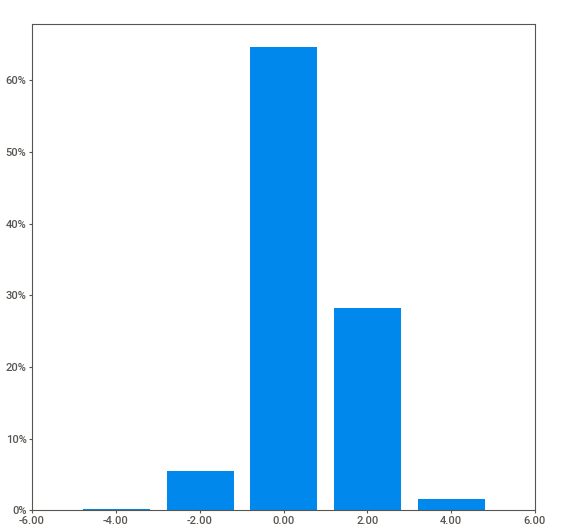
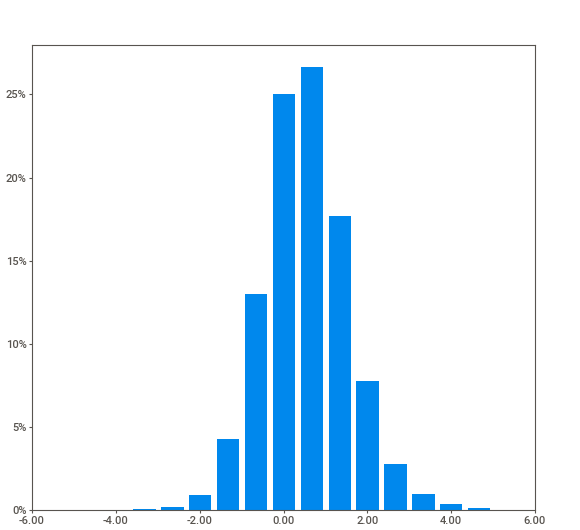
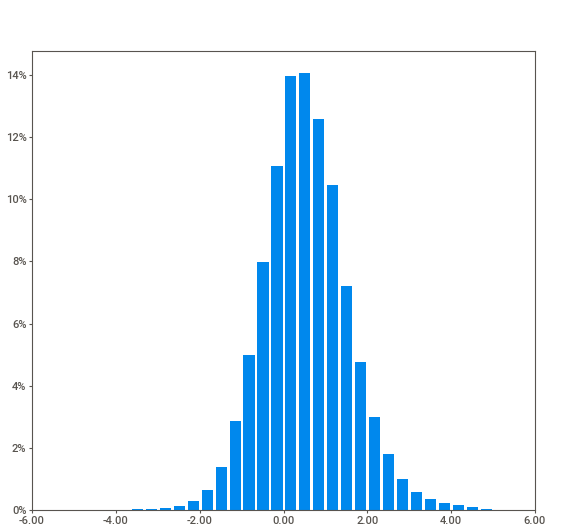
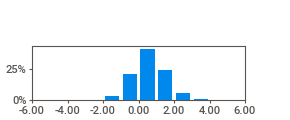
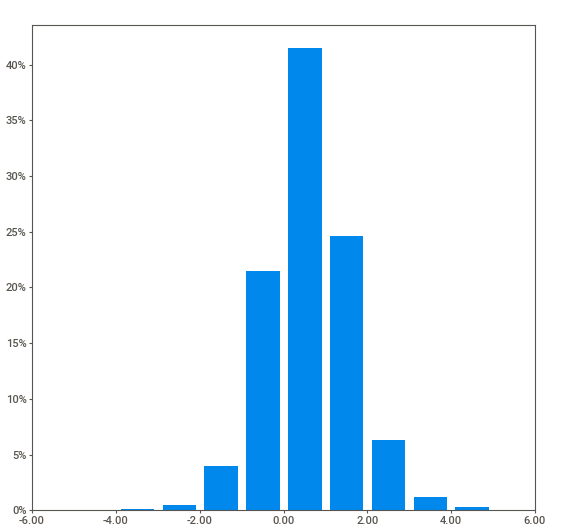
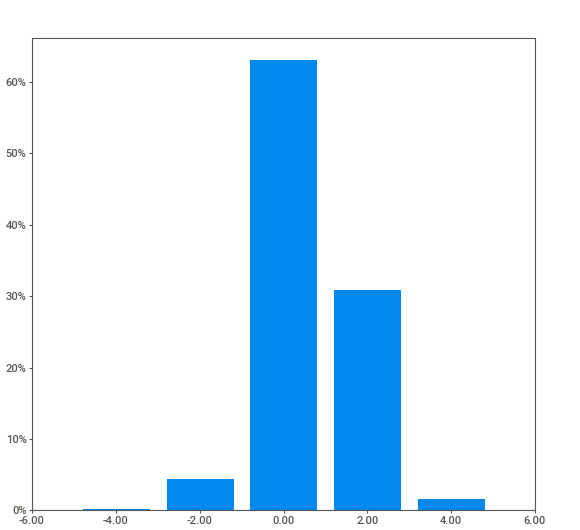
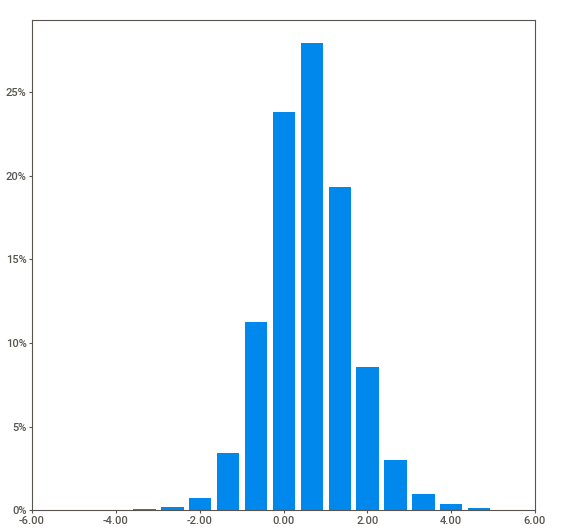
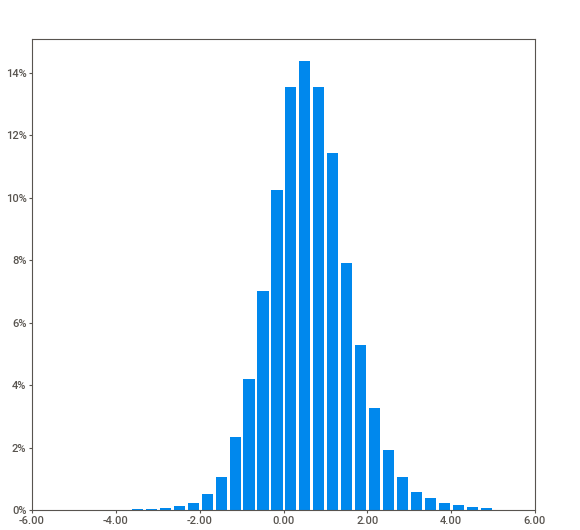
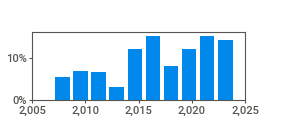
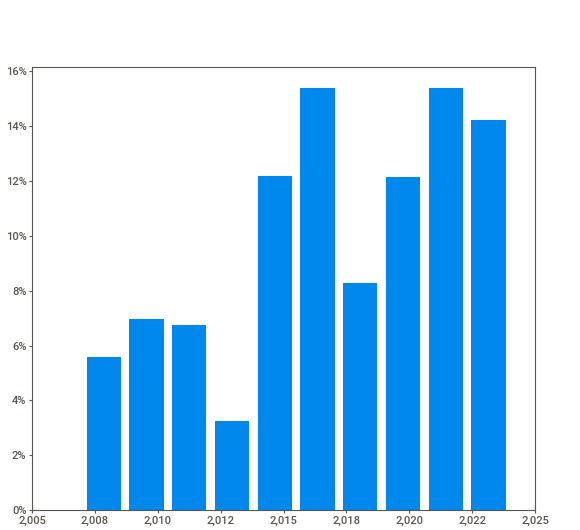
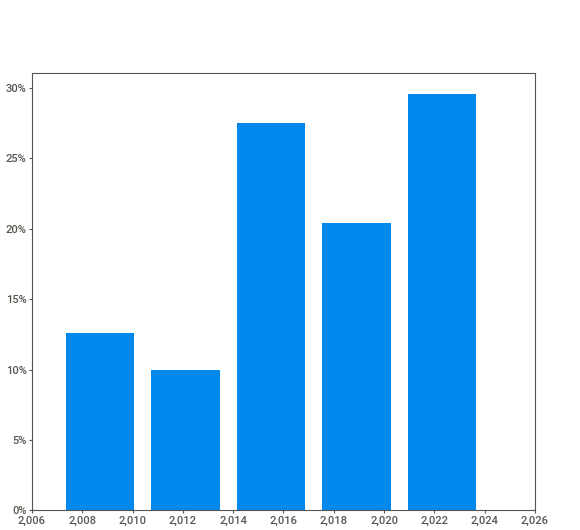
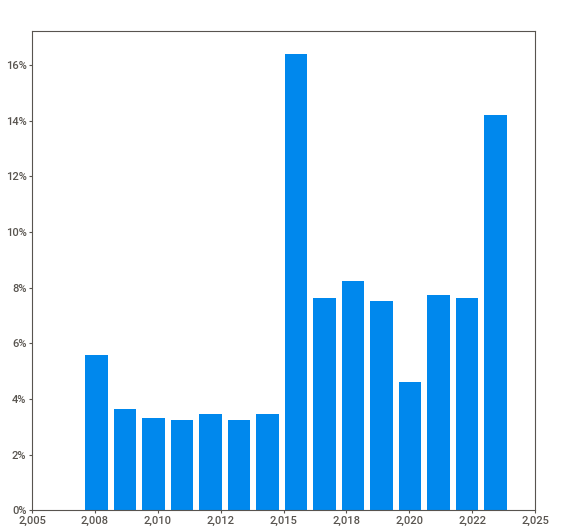
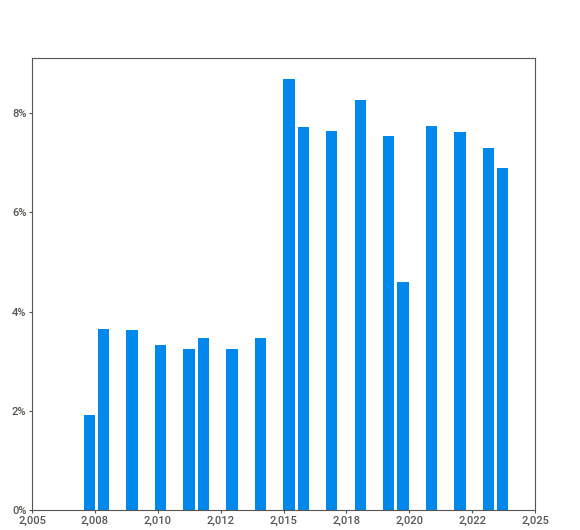
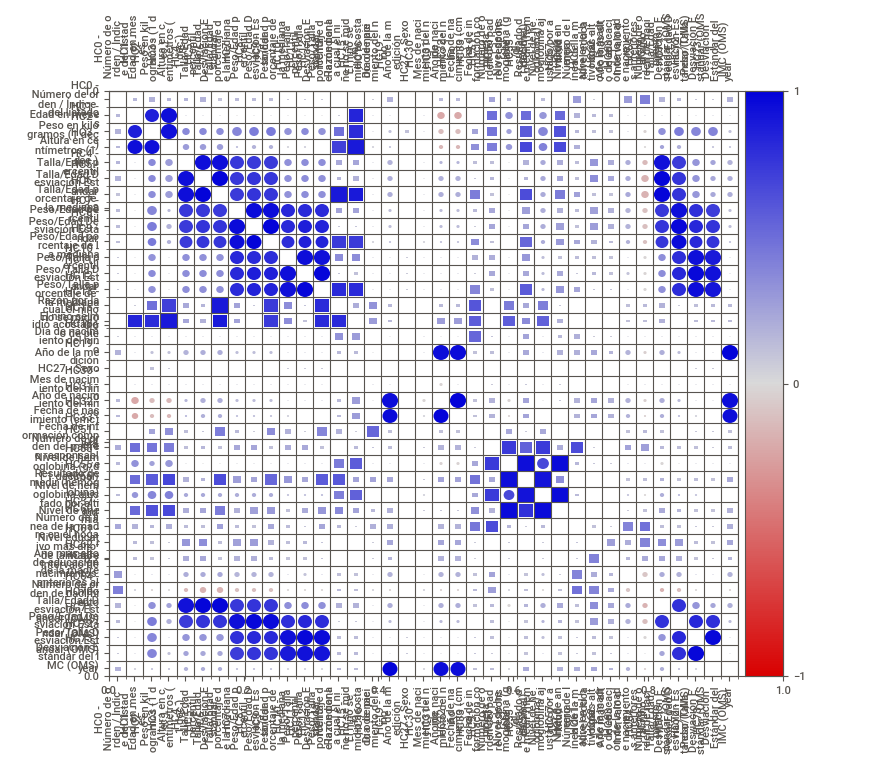
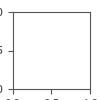

Report '/Users/abelguevarah/Desktop/invs/malnutrition-research/data/interim/rech6_sweetviz_report.html' was saved to storage.


In [11]:
import sweetviz as sv
from mnp.configs.column_labels import SWEETVIZ_LABELS
from mnp.config import INTERIM_DATA_DIR  # Importamos tu variable mágica

df_sweetviz = df_final.rename(columns=SWEETVIZ_LABELS)
reporte_sv = sv.analyze(df_sweetviz)

# Usamos la ruta absoluta inteligente y la pasamos a string
ruta_reporte = str(INTERIM_DATA_DIR / 'rech6_sweetviz_report.html')

reporte_sv.show_html(ruta_reporte)
reporte_sv.show_notebook(w="100%", h="800", filepath=ruta_reporte)
